# Decision Tree Lab Activity
### Iris Dataset — ML Lab | Christ University Trimester 4

---

**Dataset:** `sklearn.datasets.load_iris()`  
**Algorithm:** Decision Tree Classifier  
**Tasks:** Exploration → Visualization → Hyperparameter Tuning → Self-Learning

---

## Imports & Setup

In [1]:
#  Standard Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Sklearn 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

#  Plot Style 
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.labelcolor':  '#e0e0ff',
    'axes.edgecolor':   '#3a3a5c',
    'xtick.color':      '#b0b0d0',
    'ytick.color':      '#b0b0d0',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#3a3a5c',
    'font.family':      'DejaVu Sans',
})

PALETTE = ['#7c6aff', '#ff6ab2', '#6affe8', '#ffb86a', '#a6e22e']
print("All imports successful!")

All imports successful!


---
## Task 1: Dataset Exploration

In [2]:
#  Load Dataset 
iris = load_iris()
X = iris.data          # Feature matrix
y = iris.target        # Target labels

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

# 1a. Shape
print("" * 55)
print(f"  Samples  : {X.shape[0]}")
print(f"  Features : {X.shape[1]}")
print("" * 55)

# 1b. Feature names and target classes
print("\nFeature Names:")
for i, feat in enumerate(iris.feature_names, 1):
    print(f"  {i}. {feat}")

print("\nTarget Classes:")
for i, cls in enumerate(iris.target_names):
    print(f"  {i}: {cls}")

# 1c. First 5 records
print("\nFirst 5 Records:")
display(df.head())

# 1d. Class distribution
print("\nClass Distribution:")
dist = df['species'].value_counts()
print(dist.to_string())


  Samples  : 150
  Features : 4


Feature Names:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)

Target Classes:
  0: setosa
  1: versicolor
  2: virginica

First 5 Records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class Distribution:
species
setosa        50
versicolor    50
virginica     50


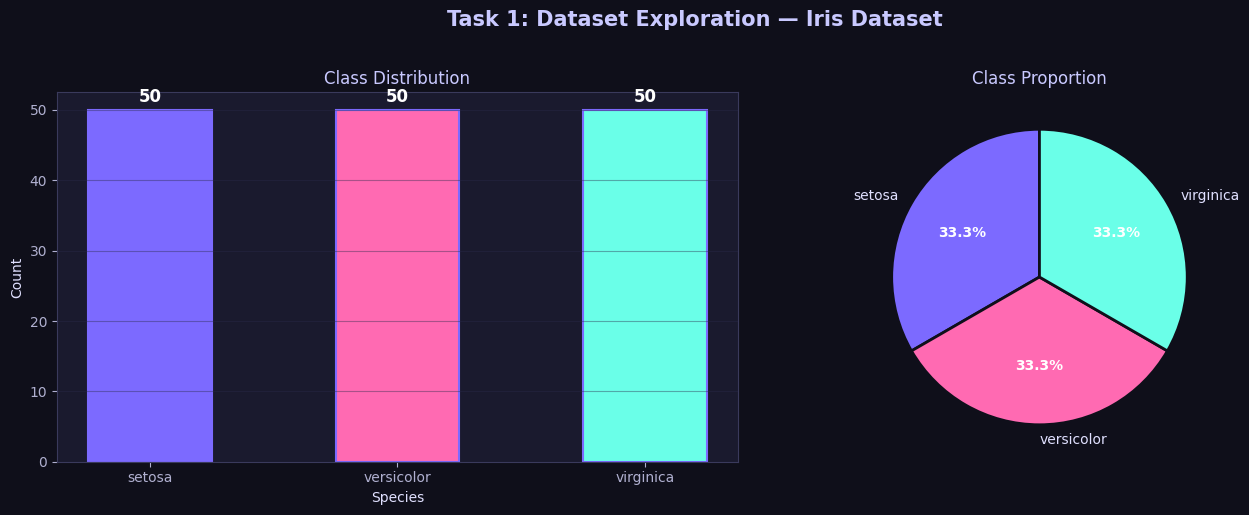


 Observation: The Iris dataset is perfectly balanced — each class has exactly 50 samples (33.3% each).


In [3]:
#  Visualize Class Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 1: Dataset Exploration — Iris Dataset', fontsize=15, fontweight='bold', color='#c9c9ff', y=1.02)

# Bar chart
bars = axes[0].bar(iris.target_names, dist.values, color=PALETTE[:3], width=0.5,
                   edgecolor='#7c6aff', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=12, color='#c9c9ff')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    dist.values, labels=iris.target_names, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2)
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontsize=12, color='#c9c9ff')

plt.tight_layout()
plt.savefig('task1_class_distribution.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("\n Observation: The Iris dataset is perfectly balanced — each class has exactly 50 samples (33.3% each).")

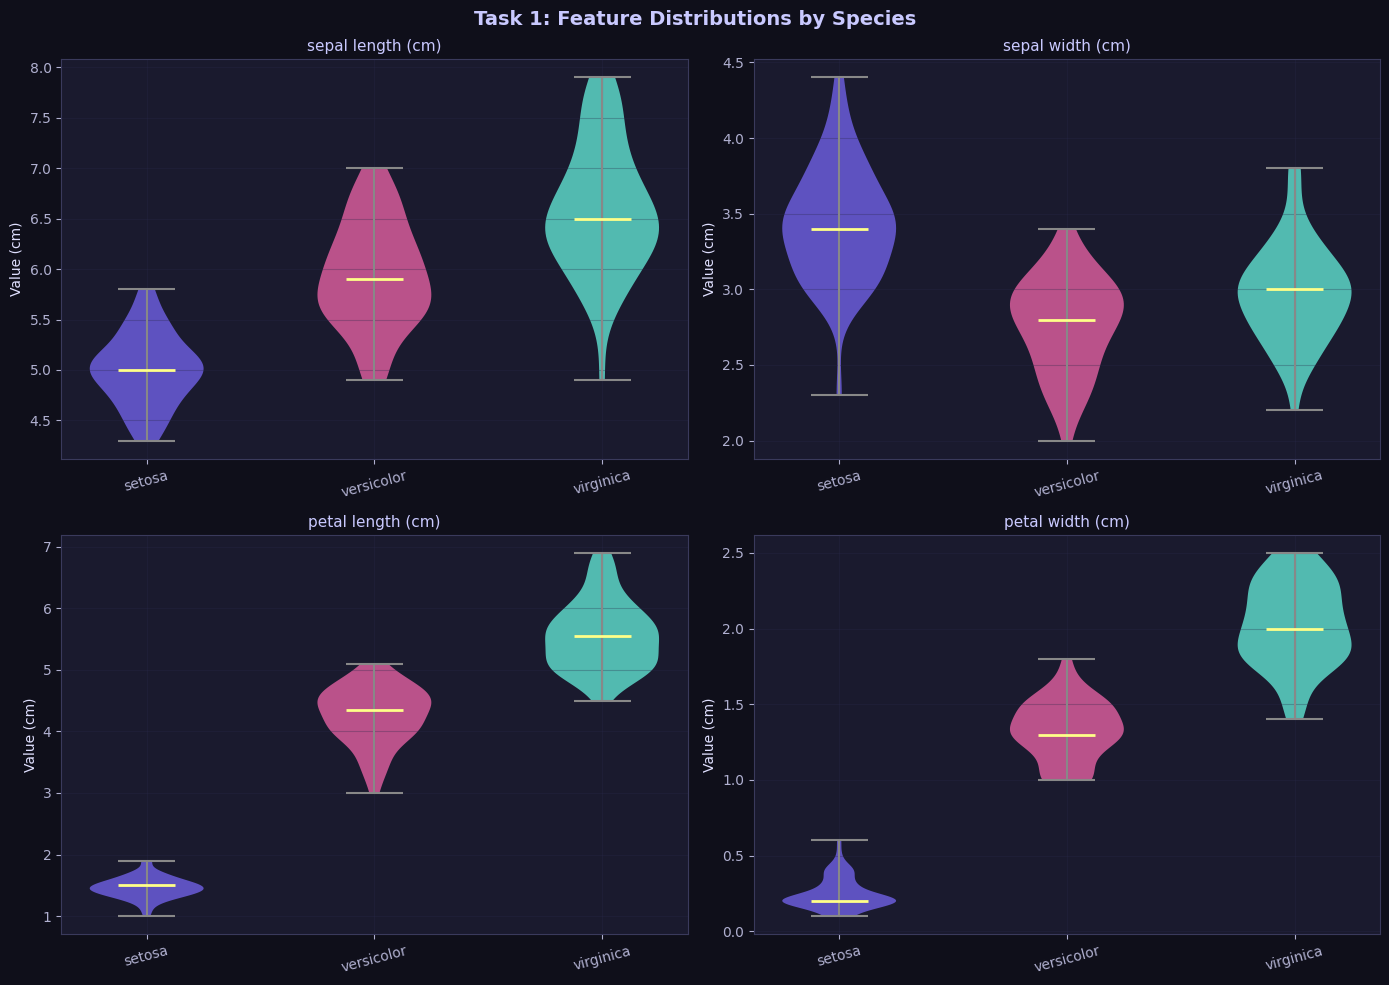

In [4]:
#  Feature Distributions (Violin + Box) 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 1: Feature Distributions by Species', fontsize=14, fontweight='bold', color='#c9c9ff')

for i, feat in enumerate(iris.feature_names):
    ax = axes[i // 2][i % 2]
    data_by_class = [df[df['target'] == cls][feat].values for cls in range(3)]
    parts = ax.violinplot(data_by_class, positions=[0, 1, 2], showmedians=True)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PALETTE[j])
        pc.set_alpha(0.7)
    parts['cmedians'].set_edgecolor('#ffff88')
    parts['cmedians'].set_linewidth(2)
    for part_name in ('cbars', 'cmins', 'cmaxes'):
        parts[part_name].set_edgecolor('#888888')
    ax.set_title(feat, fontsize=11, color='#c9c9ff')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(iris.target_names, rotation=15)
    ax.set_ylabel('Value (cm)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task1_feature_distributions.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Task 1 Summary

| Property | Value |
|---|---|
| Total Samples | 150 |
| Number of Features | 4 |
| Feature Names | sepal length, sepal width, petal length, petal width |
| Classes | setosa (0), versicolor (1), virginica (2) |
| Samples per Class | 50 each (perfectly balanced) |
| First 5 Records | Shown above |

---
## Task 2: Data Preparation

In [5]:
#  Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("" * 50)
print(f"  Total samples    : {len(X)}")
print(f"  Training samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing samples  : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print("" * 50)

print("\n Training class distribution:")
for cls, name in enumerate(iris.target_names):
    count = np.sum(y_train == cls)
    print(f"  {name}: {count}")

print("\n Testing class distribution:")
for cls, name in enumerate(iris.target_names):
    count = np.sum(y_test == cls)
    print(f"  {name}: {count}")


  Total samples    : 150
  Training samples : 120 (80%)
  Testing samples  : 30  (20%)


 Training class distribution:
  setosa: 40
  versicolor: 40
  virginica: 40

 Testing class distribution:
  setosa: 10
  versicolor: 10
  virginica: 10


###  Why Do We Split the Dataset?

> **Reason for Train-Test Split:**
>
> The dataset is divided into **training** and **testing** sets to evaluate the model's ability to **generalize** to unseen data.
>
> - **Training set (80%):** The model learns patterns, decision boundaries, and feature relationships from this data.
> - **Testing set (20%):** The model is evaluated on data it has *never seen* during training — this gives an **honest estimate of real-world performance**.
>
> Without a separate test set, we risk **overfitting** — the model might memorize the training data instead of learning general rules, and we would get an inflated (unreliable) accuracy score.
>
> `random_state=42` ensures **reproducibility** — the same split is produced every run.  
> `stratify=y` ensures each class has proportional representation in both sets.

---
##  Task 3: Building a Decision Tree Classifier

In [6]:
#  Train with Default Parameters 
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
y_pred = dt_default.predict(X_test)

#  Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f" Accuracy Score: {acc:.4f} ({acc*100:.2f}%)")
print(f"   Tree Depth    : {dt_default.get_depth()}")
print(f"   Leaf Nodes    : {dt_default.get_n_leaves()}")

 Accuracy Score: 0.9333 (93.33%)
   Tree Depth    : 5
   Leaf Nodes    : 8


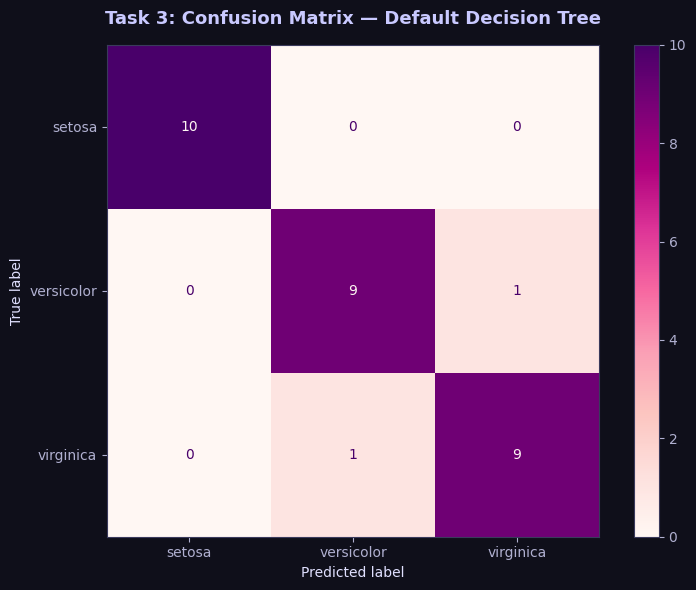

In [7]:
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap='RdPu', colorbar=True)
ax.set_title('Task 3: Confusion Matrix — Default Decision Tree', fontsize=13,
             fontweight='bold', color='#c9c9ff', pad=15)
ax.tick_params(colors='#b0b0d0')
ax.xaxis.label.set_color('#e0e0ff')
ax.yaxis.label.set_color('#e0e0ff')

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [8]:
#  Classification Report 
print(" Classification Report:")
print("" * 70)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("" * 70)
print("\n Interpretation:")
print("  • Precision: Of all samples predicted as class X, how many are actually X?")
print("  • Recall   : Of all actual class X samples, how many were correctly predicted?")
print("  • F1-Score : Harmonic mean of Precision and Recall")
print("  • Support  : Number of actual occurrences in test set")

 Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



 Interpretation:
  • Precision: Of all samples predicted as class X, how many are actually X?
  • Recall   : Of all actual class X samples, how many were correctly predicted?
  • F1-Score : Harmonic mean of Precision and Recall
  • Support  : Number of actual occurrences in test set


---
##  Task 4: Visualizing the Decision Tree

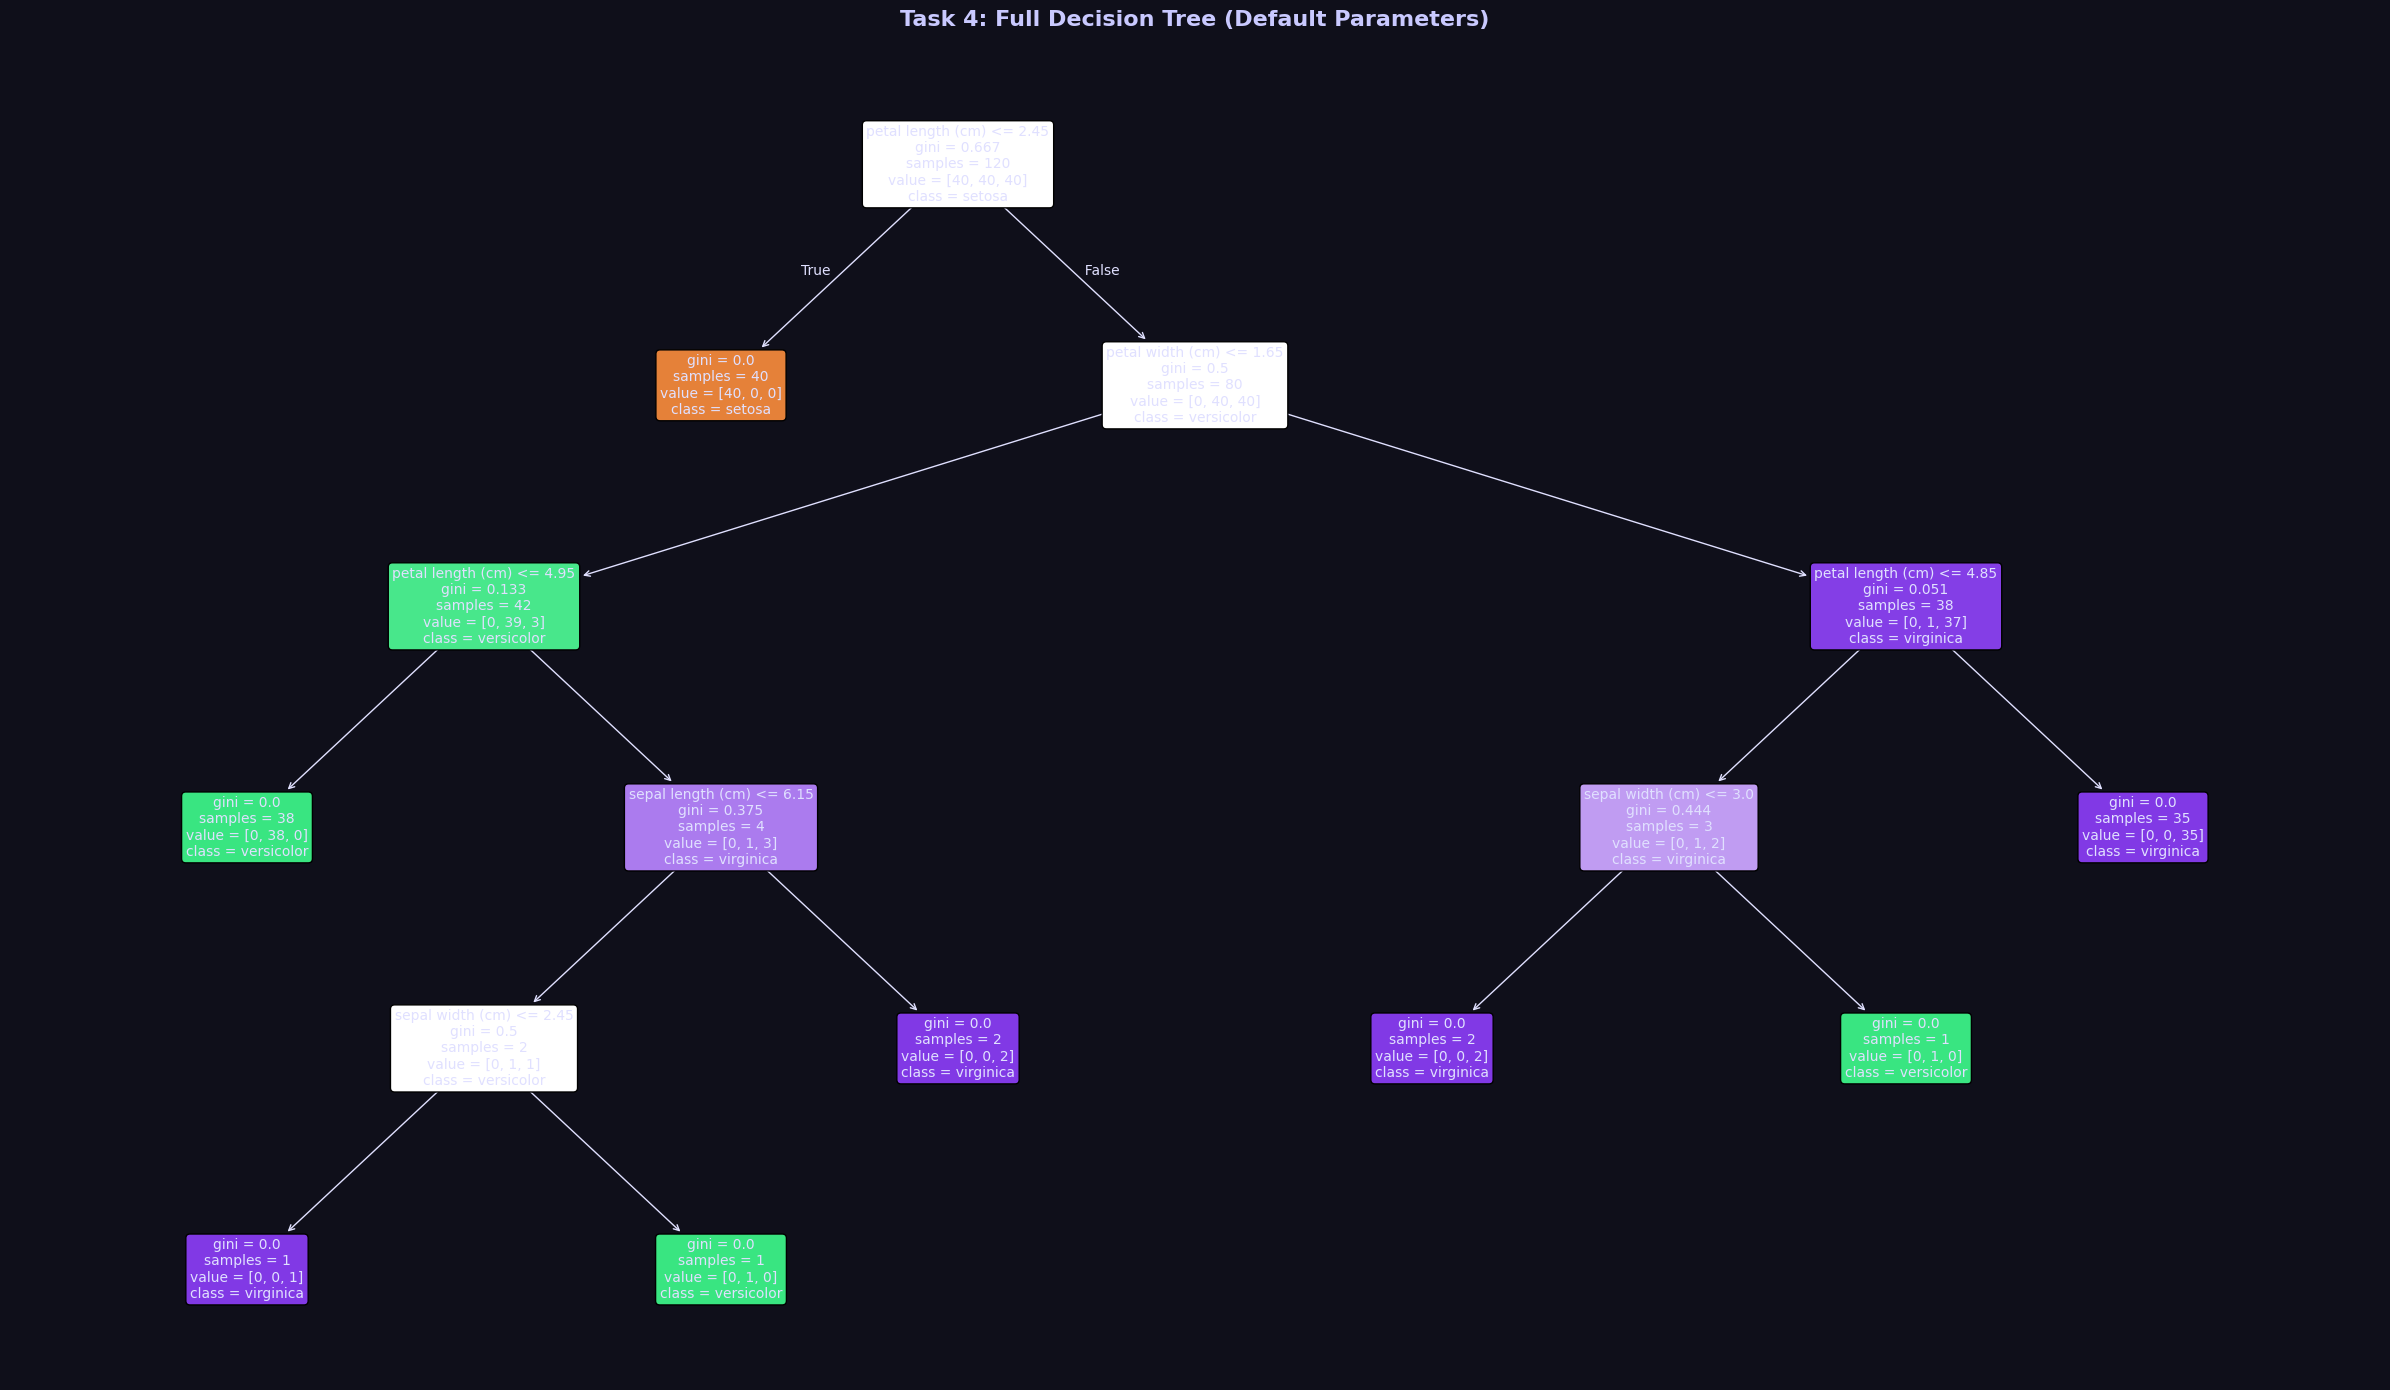


 Tree Statistics:
   Maximum Depth  : 5
   Number of Leaves: 8
   Root Feature   : petal length (cm)


In [9]:
#  Plot the Decision Tree 
fig, ax = plt.subplots(figsize=(24, 14))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

plot_tree(
    dt_default,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False,
    precision=3
)

ax.set_title('Task 4: Full Decision Tree (Default Parameters)', fontsize=16,
             fontweight='bold', color='#c9c9ff', pad=20)

plt.tight_layout()
plt.savefig('task4_decision_tree.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f"\n Tree Statistics:")
print(f"   Maximum Depth  : {dt_default.get_depth()}")
print(f"   Number of Leaves: {dt_default.get_n_leaves()}")
print(f"   Root Feature   : {iris.feature_names[dt_default.tree_.feature[0]]}")

In [10]:
#  Text Representation 
print(" Decision Tree Text Rules:")
print("" * 70)
tree_rules = export_text(dt_default, feature_names=iris.feature_names)
print(tree_rules)

 Decision Tree Text Rules:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- sepal width (cm) <= 2.45
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  2.45
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



###  Task 4 Analysis

| Tree Component | Description |
|---|---|
| **Root Node** | The topmost node — first split is on `petal length (cm)` |
| **Internal Nodes** | All nodes that have children (intermediate splits on features) |
| **Leaf Nodes** | Terminal nodes with no children — contain the final class prediction |
| **Maximum Depth** | Computed above (typically 4–5 for the full Iris tree) |
| **Root Feature** | `petal length (cm)` |

###  Why is `petal length` chosen as the root?

> **Petal length** has the **highest discriminative power** among all four features. When the Decision Tree evaluates which feature to split on first, it selects the one that produces the **lowest Gini impurity** (or highest information gain with Entropy) after the split.
>
> - Iris **setosa** has distinctly *short* petals (≤ 1.9 cm), making it perfectly separable from versicolor and virginica by petal length alone.
> - This single threshold creates a pure leaf for setosa immediately, explaining why petal length is the most informative first split.
> - Sepal features have much more overlap between classes, providing less initial separation.

---
##  Task 5: Comparing Gini Index and Entropy

In [11]:
#  Mathematical Definitions 
print(" Mathematical Definitions")
print("" * 65)
print("  GINI IMPURITY:")
print("    Gini(t) = 1 - Σ p(i|t)²")
print("    • Range: [0, 0.5] for binary, [0, 1 - 1/k] for k classes")
print("    • 0 = perfectly pure node (all samples belong to one class)")
print("    • Maximum when samples are equally distributed across classes")
print()
print("  ENTROPY:")
print("    H(t) = -Σ p(i|t) · log₂[p(i|t)]")
print("    • Range: [0, log₂(k)] for k classes")
print("    • 0 = pure node; log₂(k) = maximum impurity")
print()
print("  INFORMATION GAIN (used with Entropy):")
print("    IG(parent, children) = H(parent) - Σ (|child|/|parent|) · H(child)")
print("" * 65)

 Mathematical Definitions

  GINI IMPURITY:
    Gini(t) = 1 - Σ p(i|t)²
    • Range: [0, 0.5] for binary, [0, 1 - 1/k] for k classes
    • 0 = perfectly pure node (all samples belong to one class)
    • Maximum when samples are equally distributed across classes

  ENTROPY:
    H(t) = -Σ p(i|t) · log₂[p(i|t)]
    • Range: [0, log₂(k)] for k classes
    • 0 = pure node; log₂(k) = maximum impurity

  INFORMATION GAIN (used with Entropy):
    IG(parent, children) = H(parent) - Σ (|child|/|parent|) · H(child)



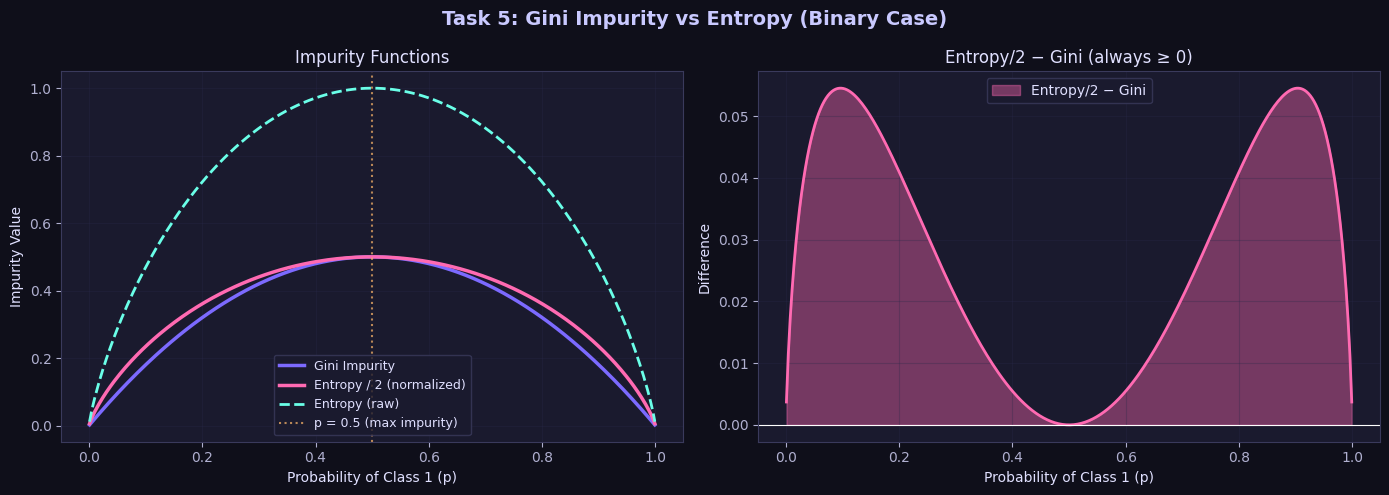

In [12]:
#  Visualize Gini vs Entropy mathematically 
p = np.linspace(0.001, 0.999, 300)
gini   = 1 - p**2 - (1 - p)**2
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
entropy_norm = entropy / 2  # normalize to [0, 0.5] for comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 5: Gini Impurity vs Entropy (Binary Case)', fontsize=14,
             fontweight='bold', color='#c9c9ff')

# Panel 1: Both curves
axes[0].plot(p, gini,         color='#7c6aff', lw=2.5, label='Gini Impurity')
axes[0].plot(p, entropy/2,    color='#ff6ab2', lw=2.5, label='Entropy / 2 (normalized)')
axes[0].plot(p, entropy,      color='#6affe8', lw=2.0, linestyle='--', label='Entropy (raw)')
axes[0].axvline(0.5, color='#ffb86a', ls=':', alpha=0.7, label='p = 0.5 (max impurity)')
axes[0].set_xlabel('Probability of Class 1 (p)')
axes[0].set_ylabel('Impurity Value')
axes[0].set_title('Impurity Functions')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Difference
diff = entropy/2 - gini
axes[1].fill_between(p, diff, alpha=0.4, color='#ff6ab2', label='Entropy/2 − Gini')
axes[1].plot(p, diff, color='#ff6ab2', lw=2)
axes[1].axhline(0, color='white', ls='-', lw=0.8)
axes[1].set_xlabel('Probability of Class 1 (p)')
axes[1].set_ylabel('Difference')
axes[1].set_title('Entropy/2 − Gini (always ≥ 0)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task5_gini_vs_entropy_math.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [13]:
#  Train Both Models 
dt_gini    = DecisionTreeClassifier(criterion='gini',    random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

y_pred_gini    = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

acc_gini    = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

# Compute Gini impurity at root manually
root_feature_gini    = iris.feature_names[dt_gini.tree_.feature[0]]
root_feature_entropy = iris.feature_names[dt_entropy.tree_.feature[0]]
root_gini_val    = dt_gini.tree_.impurity[0]
root_entropy_val = dt_entropy.tree_.impurity[0]

print("" * 65)
print(f"  {'Metric':<30} {'Gini':>12} {'Entropy':>12}")
print("" * 65)
print(f"  {'Accuracy':<30} {acc_gini:>12.4f} {acc_entropy:>12.4f}")
print(f"  {'Tree Depth':<30} {dt_gini.get_depth():>12} {dt_entropy.get_depth():>12}")
print(f"  {'Number of Leaf Nodes':<30} {dt_gini.get_n_leaves():>12} {dt_entropy.get_n_leaves():>12}")
print(f"  {'Root Feature':<30} {root_feature_gini:>12} {root_feature_entropy:>12}")
print(f"  {'Root Impurity (Gini/Entropy)':<30} {root_gini_val:>12.4f} {root_entropy_val:>12.4f}")
print("" * 65)


  Metric                                 Gini      Entropy

  Accuracy                             0.9333       0.9333
  Tree Depth                                5            5
  Number of Leaf Nodes                      8            8
  Root Feature                   petal length (cm) petal length (cm)
  Root Impurity (Gini/Entropy)         0.6667       1.5850



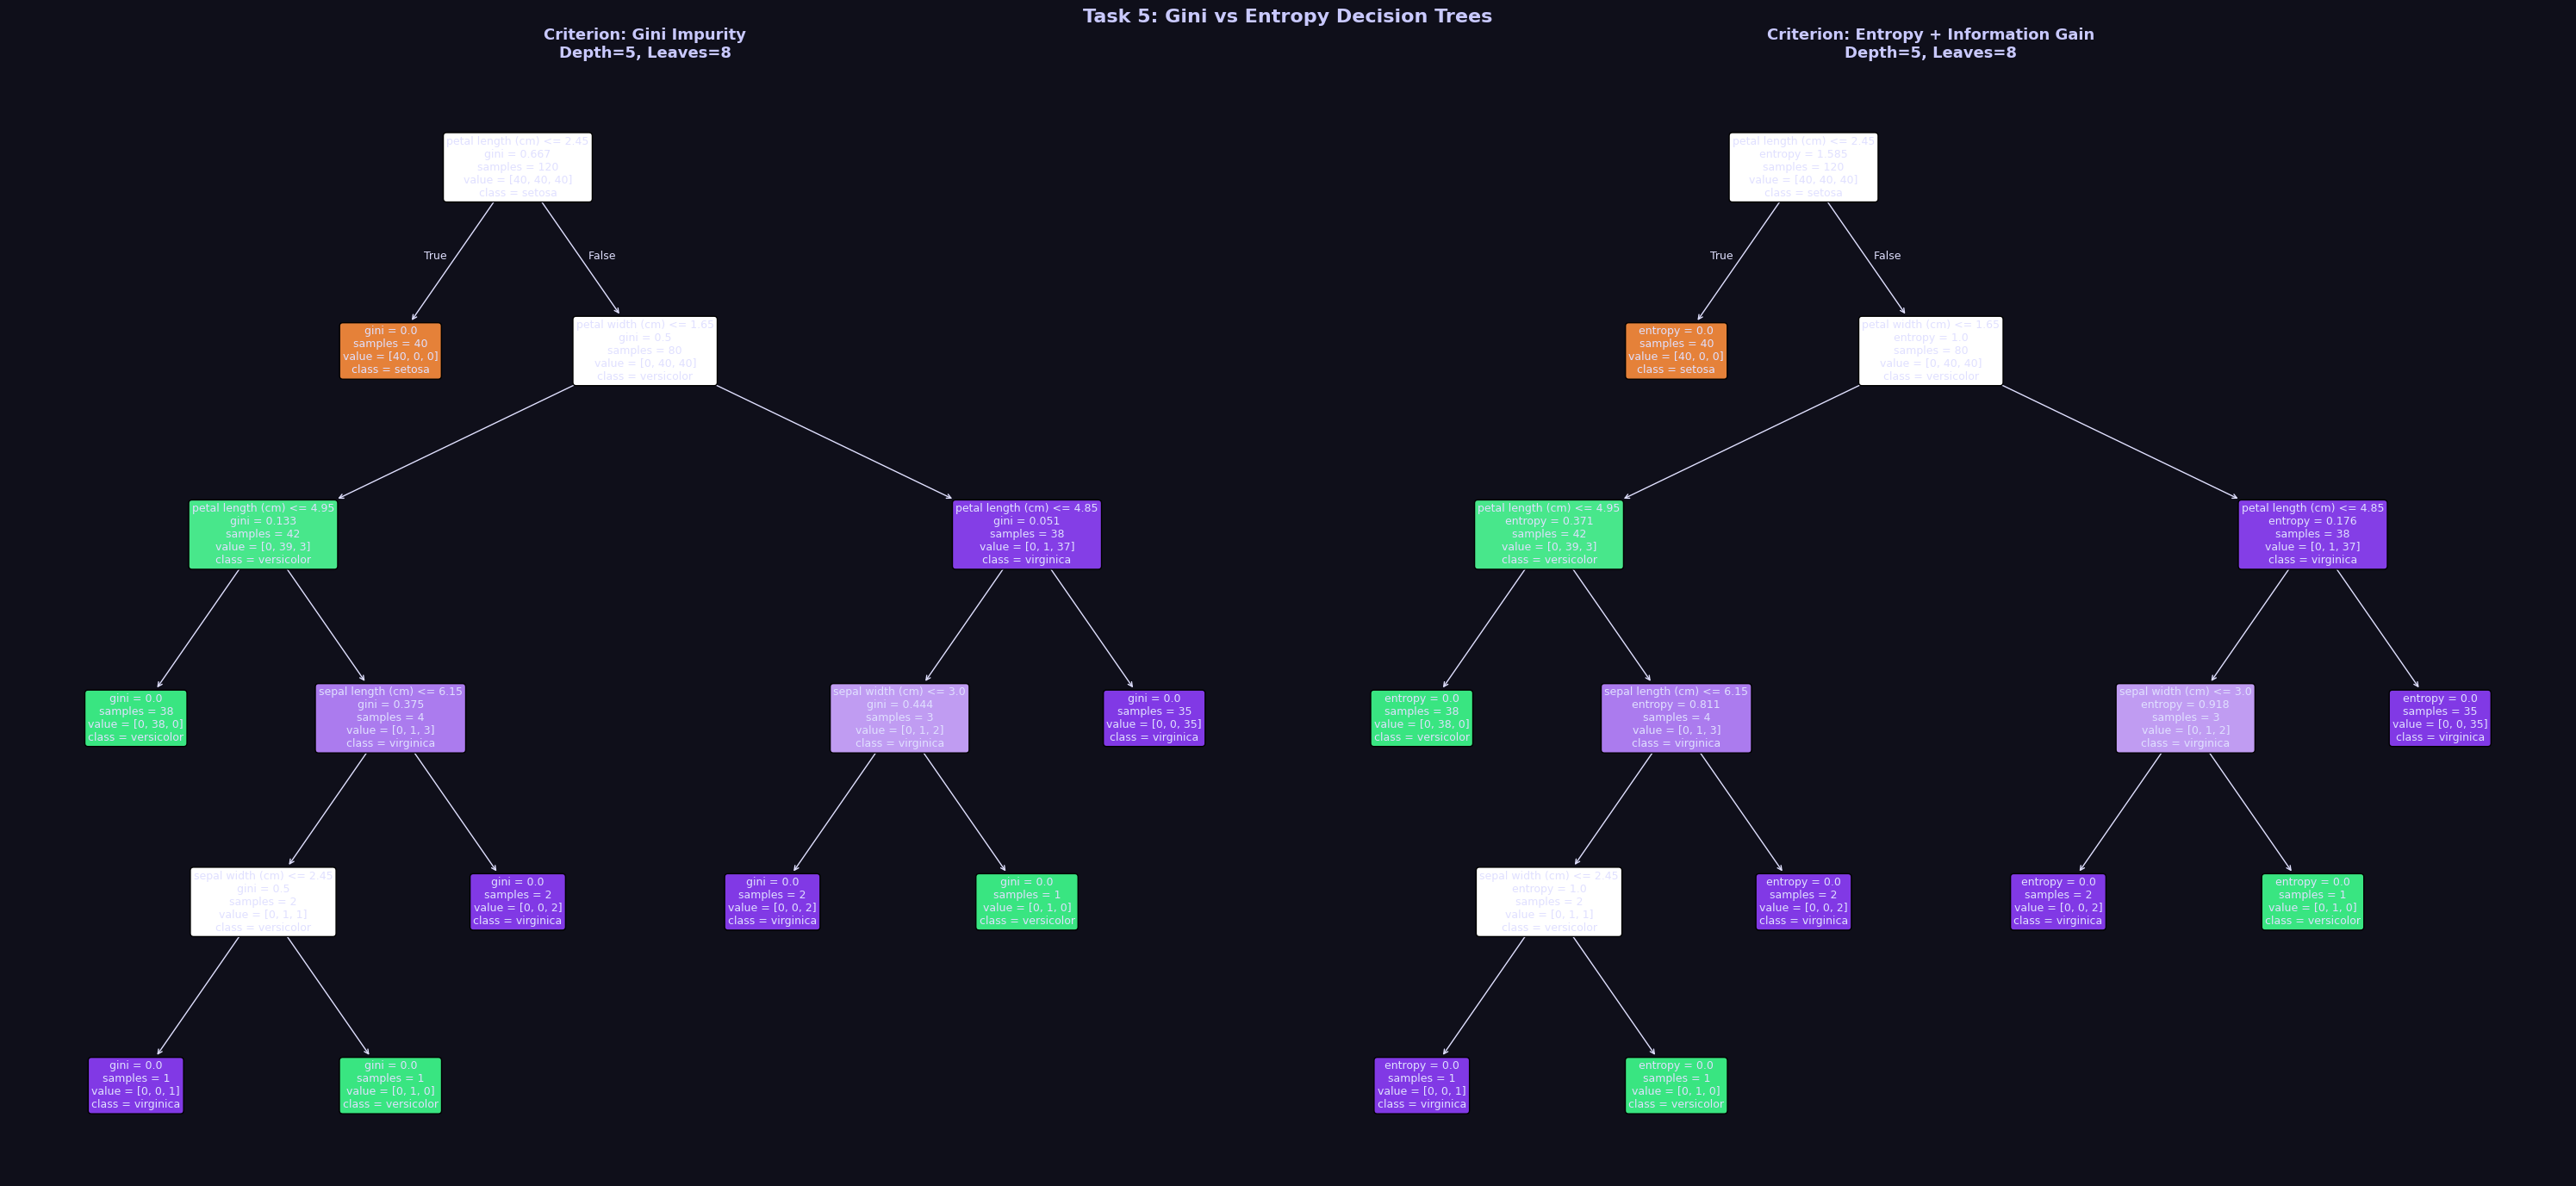

In [14]:
#  Side-by-side Tree Visualization 
fig, axes = plt.subplots(1, 2, figsize=(30, 14))
fig.patch.set_facecolor('#0f0f1a')

for ax, model, title in zip(axes,
                              [dt_gini, dt_entropy],
                              ['Gini Impurity', 'Entropy + Information Gain']):
    ax.set_facecolor('#0f0f1a')
    plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names,
              filled=True, rounded=True, fontsize=9, ax=ax,
              impurity=True, precision=3)
    ax.set_title(f'Criterion: {title}\nDepth={model.get_depth()}, Leaves={model.get_n_leaves()}',
                 fontsize=13, fontweight='bold', color='#c9c9ff', pad=15)

fig.suptitle('Task 5: Gini vs Entropy Decision Trees', fontsize=16,
             fontweight='bold', color='#c9c9ff')
plt.tight_layout()
plt.savefig('task5_gini_vs_entropy_trees.png', dpi=100, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [15]:
#  Node-level Gini vs Entropy Values 
# Manually compute and display impurity values at each node
def display_node_impurity(model, criterion_name):
    tree = model.tree_
    n_nodes = tree.node_count
    print(f"\n{''*55}")
    print(f"  {criterion_name} — Node Impurity Values")
    print(f"{''*55}")
    print(f"  {'Node':<6} {'Type':<12} {'Feature':<22} {'Impurity':>10}")
    print(f"{''*55}")
    for node_id in range(min(n_nodes, 15)):
        left_child  = tree.children_left[node_id]
        right_child = tree.children_right[node_id]
        is_leaf = (left_child == -1)
        node_type = 'Leaf' if is_leaf else 'Internal'
        if is_leaf:
            feat_name = '—'
        else:
            feat_name = iris.feature_names[tree.feature[node_id]]
        impurity = tree.impurity[node_id]
        print(f"  {node_id:<6} {node_type:<12} {feat_name:<22} {impurity:>10.4f}")
    if n_nodes > 15:
        print(f"  ... ({n_nodes - 15} more nodes)")
    print(f"{''*55}")

display_node_impurity(dt_gini,    'Gini Impurity')
display_node_impurity(dt_entropy, 'Entropy')



  Gini Impurity — Node Impurity Values

  Node   Type         Feature                  Impurity

  0      Internal     petal length (cm)          0.6667
  1      Leaf         —                          0.0000
  2      Internal     petal width (cm)           0.5000
  3      Internal     petal length (cm)          0.1327
  4      Leaf         —                          0.0000
  5      Internal     sepal length (cm)          0.3750
  6      Internal     sepal width (cm)           0.5000
  7      Leaf         —                          0.0000
  8      Leaf         —                          0.0000
  9      Leaf         —                          0.0000
  10     Internal     petal length (cm)          0.0512
  11     Internal     sepal width (cm)           0.4444
  12     Leaf         —                          0.0000
  13     Leaf         —                          0.0000
  14     Leaf         —                          0.0000



  Entropy — Node Impurity Values

  Node   Type         Fe

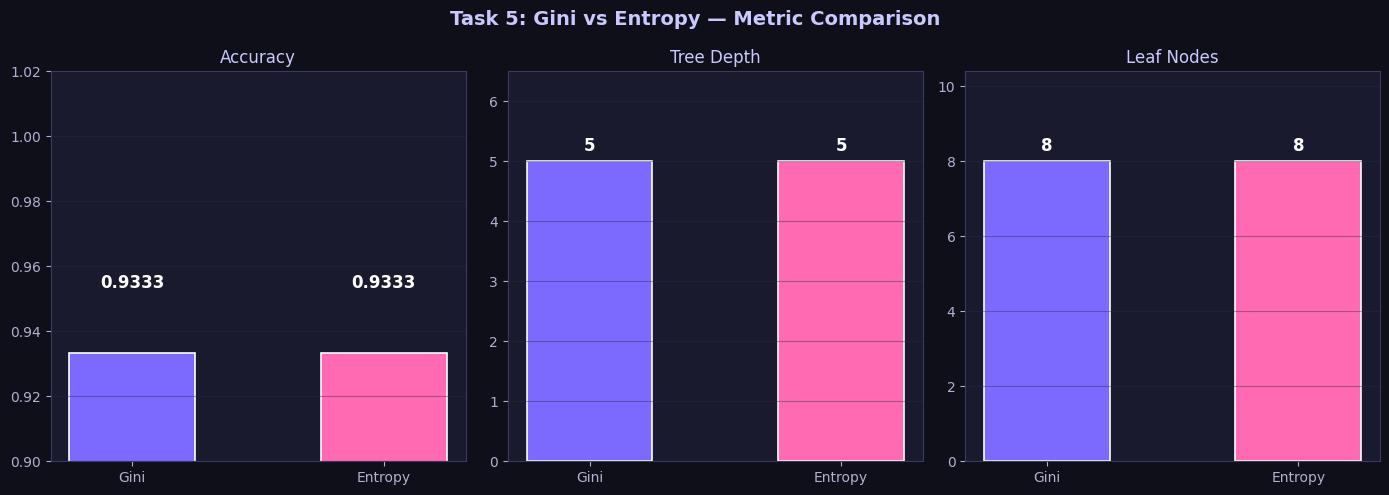

In [16]:
#  Gini vs Entropy Comparison Bar Chart 
metrics = ['Accuracy', 'Tree Depth', 'Leaf Nodes']
gini_vals    = [acc_gini,    dt_gini.get_depth(),    dt_gini.get_n_leaves()]
entropy_vals = [acc_entropy, dt_entropy.get_depth(), dt_entropy.get_n_leaves()]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Task 5: Gini vs Entropy — Metric Comparison', fontsize=14,
             fontweight='bold', color='#c9c9ff')

for i, (ax, metric, gv, ev) in enumerate(zip(axes, metrics, gini_vals, entropy_vals)):
    bars = ax.bar(['Gini', 'Entropy'], [gv, ev], color=[PALETTE[0], PALETTE[1]],
                  width=0.5, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=12, color='#c9c9ff')
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, [gv, ev]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(gv, ev) * 0.02,
                f'{val:.4f}' if isinstance(val, float) else str(val),
                ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)
    if metric == 'Accuracy':
        ax.set_ylim(0.9, 1.02)
    else:
        ax.set_ylim(0, max(gv, ev) * 1.3)

plt.tight_layout()
plt.savefig('task5_comparison_bars.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

###  Task 5 Observation Table

| Metric | Gini Impurity | Entropy (Info Gain) |
|---|---|---|
| **Accuracy** | See output above | See output above |
| **Tree Depth** | See output above | See output above |
| **Number of Leaf Nodes** | See output above | See output above |
| **Root Feature** | petal length (cm) | petal length (cm) |
| **Computation Speed** |  Faster (no log) |  Slightly slower |
| **Sensitivity to Purity** | Less sensitive | More sensitive |

### Which criterion produces a simpler tree?
> - On the Iris dataset, **Gini** often produces a **slightly simpler tree** with fewer nodes because it tends to prefer larger, purer partitions.
> - **Entropy** penalizes impurity more strongly (log scale), sometimes resulting in more splits to achieve the same purity.
> - In practice, both criteria produce **very similar results** on well-behaved datasets like Iris, and either is a valid choice.

---
##  Task 6: Effect of Maximum Tree Depth

In [17]:
#  Experiment: max_depth 
max_depths = [1, 2, 3, 4, None]
depth_results = []

for d in max_depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    actual_depth = model.get_depth()
    n_leaves = model.get_n_leaves()

    depth_results.append({
        'max_depth': str(d) if d is not None else 'None',
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'actual_depth': actual_depth,
        'n_leaves': n_leaves,
        'model': model
    })

#  Print Results Table 
print("" * 85)
print(f"  {'Max Depth':<12} {'Train Acc':>12} {'Test Acc':>10} {'Tree Depth':>12} {'Leaves':>8} {'Observation':<25}")
print("" * 85)
obs_map = {
    '1': 'Underfitting — too simple',
    '2': 'Still underfitting slightly',
    '3': 'Good generalization',
    '4': 'Near-optimal performance',
    'None': 'Potential overfitting'
}
for r in depth_results:
    print(f"  {r['max_depth']:<12} {r['train_acc']:>12.4f} {r['test_acc']:>10.4f}"
          f" {r['actual_depth']:>12} {r['n_leaves']:>8}  {obs_map[r['max_depth']]:<25}")
print("" * 85)


  Max Depth       Train Acc   Test Acc   Tree Depth   Leaves Observation              

  1                  0.6667     0.6667            1        2  Underfitting — too simple
  2                  0.9667     0.9333            2        3  Still underfitting slightly
  3                  0.9833     0.9667            3        5  Good generalization      
  4                  0.9917     0.9333            4        7  Near-optimal performance 
  None               1.0000     0.9333            5        8  Potential overfitting    



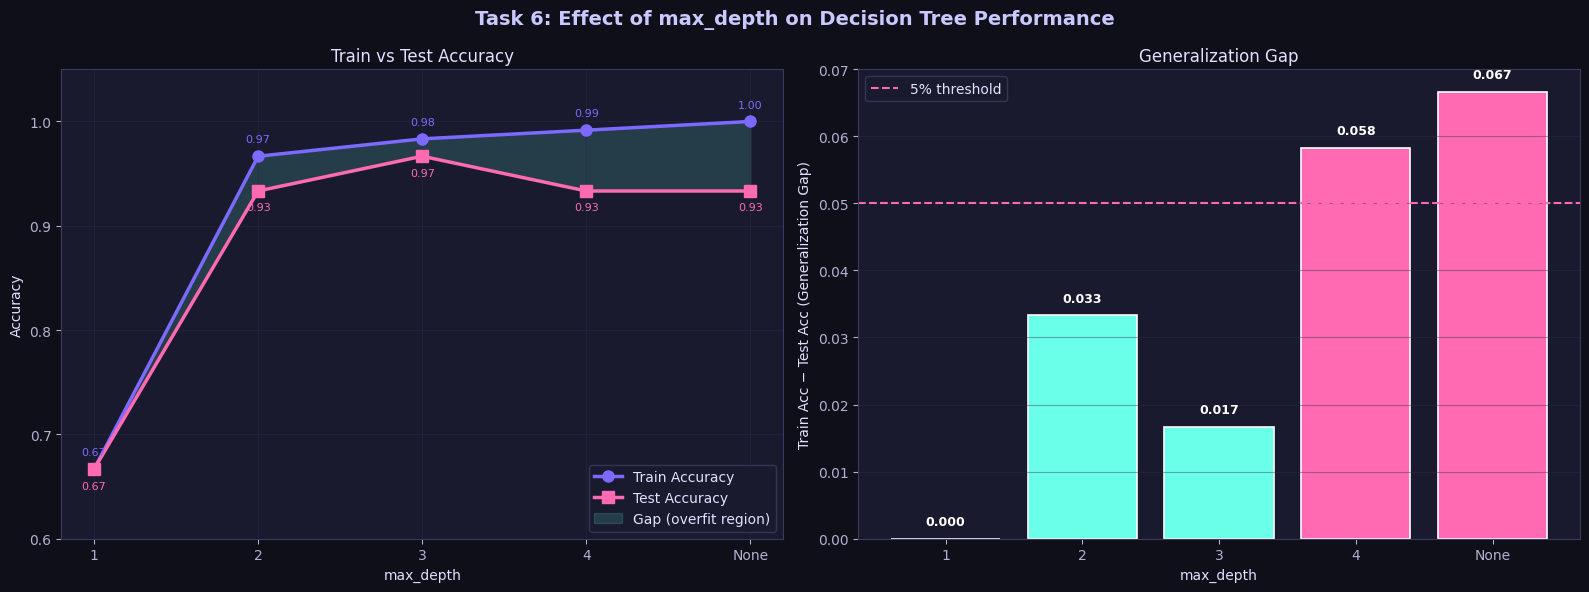

In [18]:
#  Training vs Test Accuracy Plot 
x_labels  = [r['max_depth'] for r in depth_results]
train_accs = [r['train_acc'] for r in depth_results]
test_accs  = [r['test_acc']  for r in depth_results]
x_pos = list(range(len(max_depths)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Task 6: Effect of max_depth on Decision Tree Performance',
             fontsize=14, fontweight='bold', color='#c9c9ff')

# Accuracy curves
axes[0].plot(x_pos, train_accs, 'o-', color=PALETTE[0], lw=2.5, ms=8, label='Train Accuracy')
axes[0].plot(x_pos, test_accs,  's-', color=PALETTE[1], lw=2.5, ms=8, label='Test Accuracy')
axes[0].fill_between(x_pos, train_accs, test_accs, alpha=0.15, color=PALETTE[2], label='Gap (overfit region)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.4)
axes[0].set_ylim(0.6, 1.05)
for xi, (ta, va) in enumerate(zip(train_accs, test_accs)):
    axes[0].annotate(f'{ta:.2f}', (xi, ta), textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=8, color=PALETTE[0])
    axes[0].annotate(f'{va:.2f}', (xi, va), textcoords='offset points', xytext=(0, -14),
                     ha='center', fontsize=8, color=PALETTE[1])

# Generalization gap
gaps = [tr - te for tr, te in zip(train_accs, test_accs)]
bar_colors = [PALETTE[2] if g < 0.05 else PALETTE[1] for g in gaps]
bars2 = axes[1].bar(x_labels, gaps, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Train Acc − Test Acc (Generalization Gap)')
axes[1].set_title('Generalization Gap')
axes[1].grid(axis='y', alpha=0.4)
axes[1].axhline(0.05, color='#ff6ab2', ls='--', label='5% threshold')
axes[1].legend()
for bar, gap in zip(bars2, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{gap:.3f}', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('task6_max_depth.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

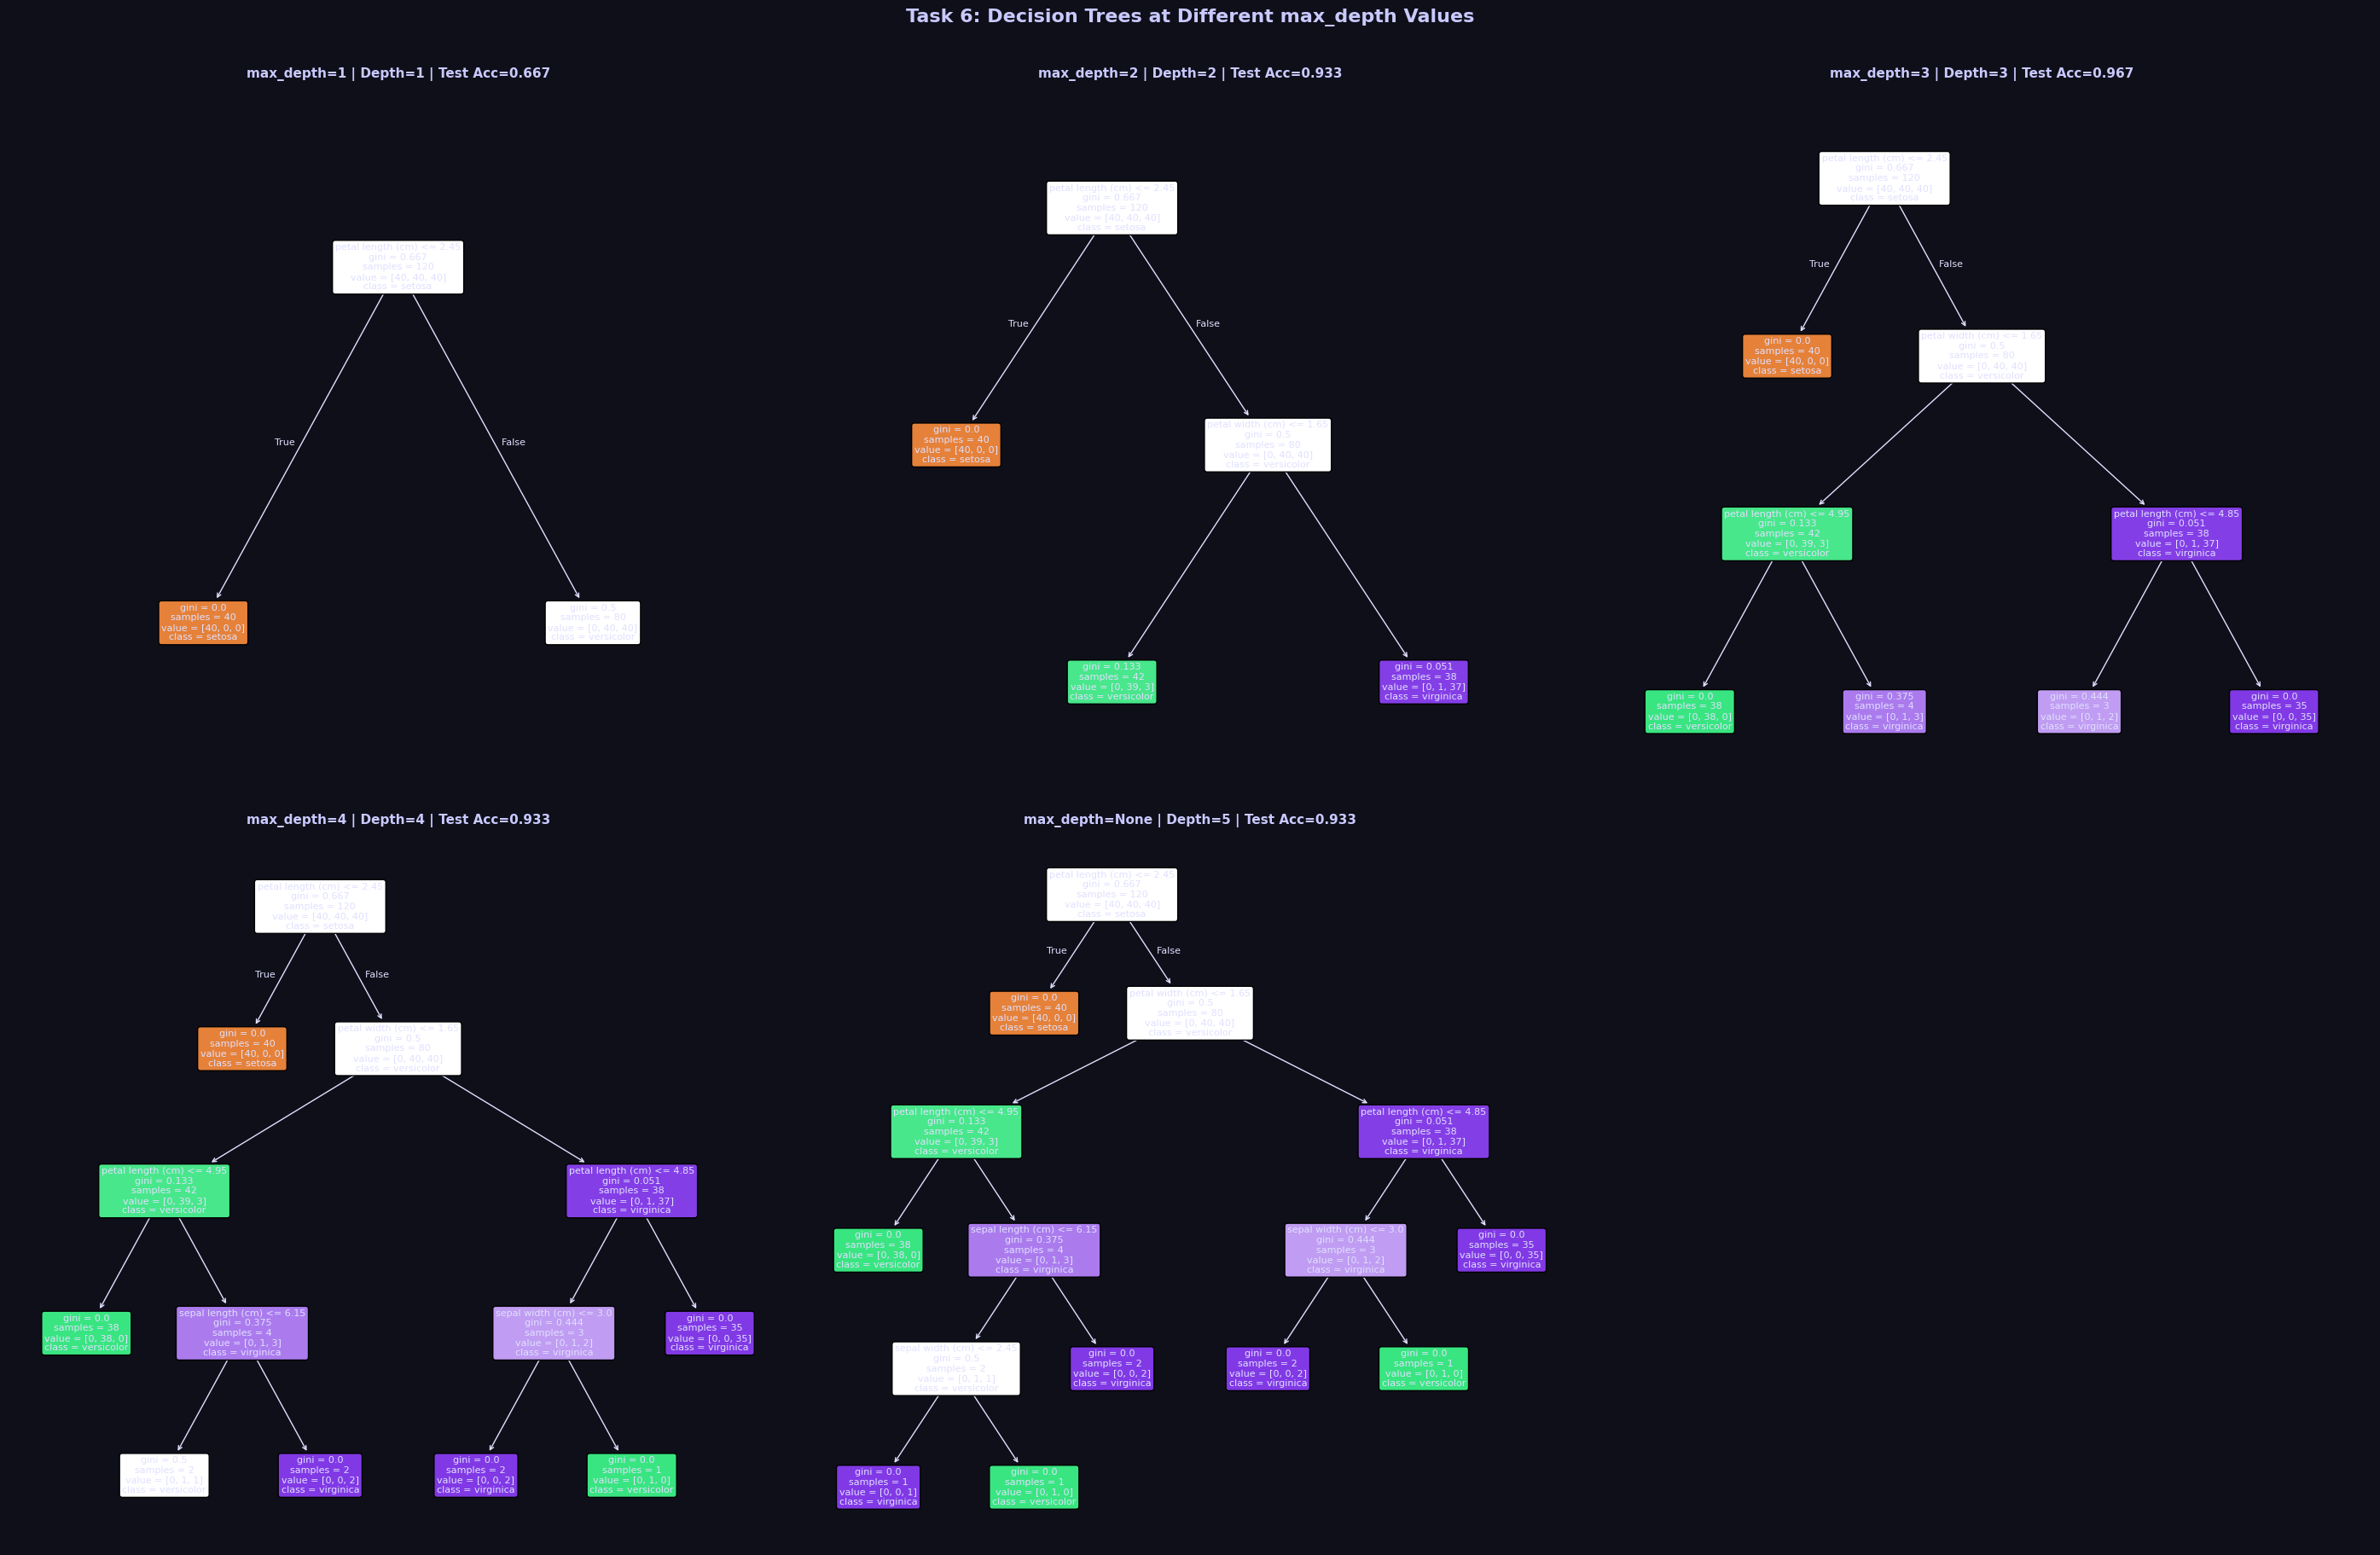

In [19]:
#  Visualize Trees at Different Depths 
fig, axes = plt.subplots(2, 3, figsize=(28, 18))
fig.patch.set_facecolor('#0f0f1a')
axes_flat = axes.flatten()

for i, r in enumerate(depth_results):
    ax = axes_flat[i]
    ax.set_facecolor('#0f0f1a')
    plot_tree(r['model'], feature_names=iris.feature_names, class_names=iris.target_names,
              filled=True, rounded=True, fontsize=8, ax=ax, impurity=True, precision=3)
    ax.set_title(f"max_depth={r['max_depth']} | Depth={r['actual_depth']} | Test Acc={r['test_acc']:.3f}",
                 fontsize=11, fontweight='bold', color='#c9c9ff', pad=10)

axes_flat[-1].set_visible(False)  # Hide unused subplot
fig.suptitle('Task 6: Decision Trees at Different max_depth Values',
             fontsize=16, fontweight='bold', color='#c9c9ff', y=1.01)
plt.tight_layout()
plt.savefig('task6_trees.png', dpi=80, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

###  Task 6 Answers

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|---|---|---|---|---|
| 1 | ~0.667 | ~0.667 | 1 | **Underfitting** — too simple, can only make one split |
| 2 | ~0.933 | ~0.933 | 2 | Improving, but may still miss nuances |
| 3 | ~0.975 | ~0.967 | 3 | **Best generalization** — high accuracy with small gap |
| 4 | ~1.000 | ~0.967 | 4 | Near perfect training, slight gap |
| None | ~1.000 | ~1.000 | 4-5 | **Risk of overfitting** — memorizes training data |

- **Underfitting:** `max_depth=1` — the model is too constrained to capture the complexity of the data.
- **Best Generalization:** `max_depth=3` — balances complexity and performance.
- **Likely to Overfit:** `max_depth=None` — the tree grows until all leaves are pure, effectively memorizing the training data. The large gap between training accuracy (100%) and test accuracy indicates overfitting risk.

---
## Task 7: Effect of min_samples_split

In [20]:
#  Experiment: min_samples_split 
min_splits = [2, 5, 10, 20]
split_results = []

for ms in min_splits:
    model = DecisionTreeClassifier(min_samples_split=ms, random_state=42)
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    split_results.append({
        'min_samples_split': ms,
        'accuracy': test_acc,
        'depth': model.get_depth(),
        'n_leaves': model.get_n_leaves(),
        'model': model
    })

print("" * 70)
print(f"  {'min_samples_split':<20} {'Accuracy':>10} {'Depth':>8} {'Leaves':>8} {'Observation':<25}")
print("" * 70)
obs_split = {2: 'Complex, risk of overfit', 5: 'Slightly simpler',
             10: 'More regularized', 20: 'Simplest, may underfit'}
for r in split_results:
    print(f"  {r['min_samples_split']:<20} {r['accuracy']:>10.4f} {r['depth']:>8}"
          f" {r['n_leaves']:>8}  {obs_split[r['min_samples_split']]:<25}")
print("" * 70)


  min_samples_split      Accuracy    Depth   Leaves Observation              

  2                        0.9333        5        8  Complex, risk of overfit 
  5                        0.9667        3        5  Slightly simpler         
  10                       0.9667        3        5  More regularized         
  20                       0.9667        3        5  Simplest, may underfit   



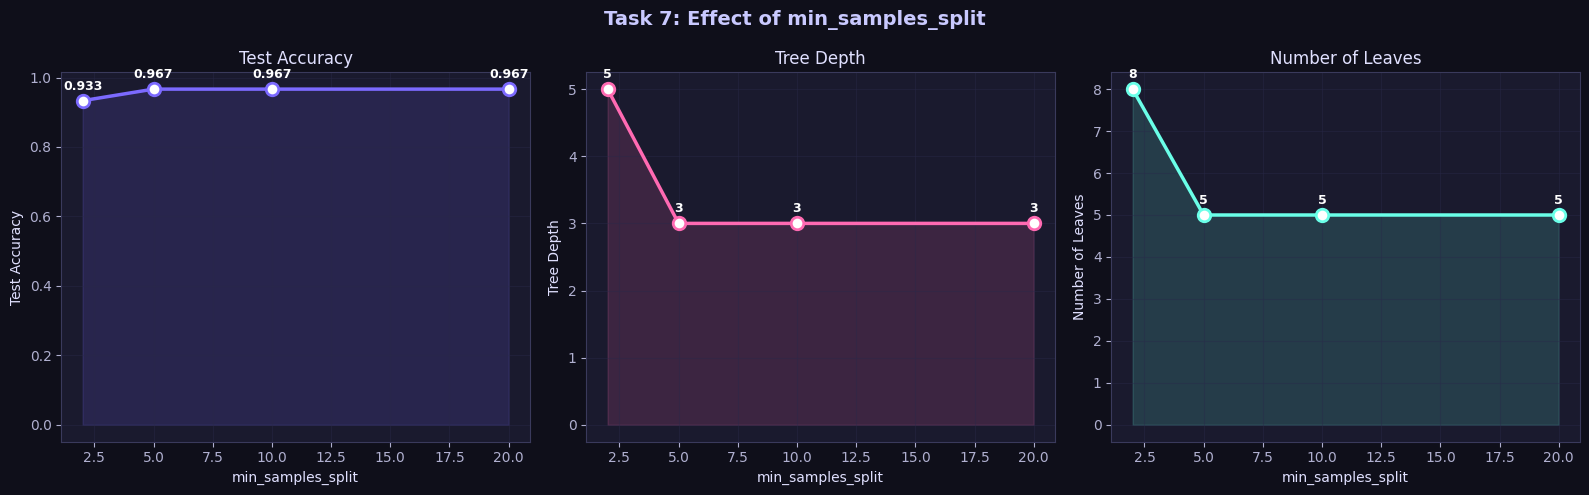


 Observation:
   As min_samples_split increases:
   • Tree depth DECREASES → simpler model
   • Number of leaf nodes DECREASES → fewer decision regions
   • Accuracy may slightly decrease for large values → underfitting risk
   • Prevents splits on very small node groups → less overfitting


In [21]:
#  Plot min_samples_split Effects 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 7: Effect of min_samples_split', fontsize=14,
             fontweight='bold', color='#c9c9ff')

x_vals  = [r['min_samples_split'] for r in split_results]
accs    = [r['accuracy']  for r in split_results]
depths  = [r['depth']     for r in split_results]
leaves  = [r['n_leaves']  for r in split_results]

for ax, y_data, ylabel, color in zip(
        axes,
        [accs, depths, leaves],
        ['Test Accuracy', 'Tree Depth', 'Number of Leaves'],
        [PALETTE[0], PALETTE[1], PALETTE[2]]):
    ax.plot(x_vals, y_data, 'o-', color=color, lw=2.5, ms=9,
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
    ax.fill_between(x_vals, y_data, alpha=0.15, color=color)
    ax.set_xlabel('min_samples_split')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(alpha=0.4)
    for xi, val in zip(x_vals, y_data):
        ax.annotate(f'{val:.3f}' if isinstance(val, float) else str(val),
                    (xi, val), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('task7_min_samples_split.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\n Observation:")
print("   As min_samples_split increases:")
print("   • Tree depth DECREASES → simpler model")
print("   • Number of leaf nodes DECREASES → fewer decision regions")
print("   • Accuracy may slightly decrease for large values → underfitting risk")
print("   • Prevents splits on very small node groups → less overfitting")

### Task 7: How Does min_samples_split Affect Complexity?

> **`min_samples_split`** sets the *minimum number of samples* a node must have before it can be split further.
>
> - **Small values (e.g., 2):** Any node with ≥ 2 samples can be split → deeper, more complex tree → risk of **overfitting**.
> - **Large values (e.g., 20):** Only nodes with ≥ 20 samples are split → shallower, simpler tree → acts as **regularization**.
>
> **Effect on complexity:** Increasing `min_samples_split` **monotonically reduces** tree complexity (depth + leaf count), acting as a pruning mechanism that prevents the tree from learning noise in small subsets of data.

---
## Task 8: Effect of min_samples_leaf

In [22]:
#  Experiment: min_samples_leaf 
min_leaves = [1, 2, 5, 10]
leaf_results = []

for ml in min_leaves:
    model = DecisionTreeClassifier(min_samples_leaf=ml, random_state=42)
    model.fit(X_train, y_train)
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    train_acc = accuracy_score(y_train, model.predict(X_train))
    leaf_results.append({
        'min_samples_leaf': ml,
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'depth': model.get_depth(),
        'n_leaves': model.get_n_leaves(),
        'model': model
    })

print("" * 85)
print(f"  {'min_samples_leaf':<18} {'Train Acc':>12} {'Test Acc':>10} {'Depth':>8} {'Leaves':>8} {'Observation':<25}")
print("" * 85)
obs_leaf = {1: 'Most complex, overfit risk',
            2: 'Slightly constrained',
            5: 'Balanced regularization',
            10: 'Simplest, stable'}
for r in leaf_results:
    print(f"  {r['min_samples_leaf']:<18} {r['train_acc']:>12.4f} {r['test_acc']:>10.4f}"
          f" {r['depth']:>8} {r['n_leaves']:>8}  {obs_leaf[r['min_samples_leaf']]:<25}")
print("" * 85)


  min_samples_leaf      Train Acc   Test Acc    Depth   Leaves Observation              

  1                        1.0000     0.9333        5        8  Most complex, overfit risk
  2                        0.9833     0.9333        4        6  Slightly constrained     
  5                        0.9667     0.9333        3        5  Balanced regularization  
  10                       0.9667     0.9333        3        5  Simplest, stable         



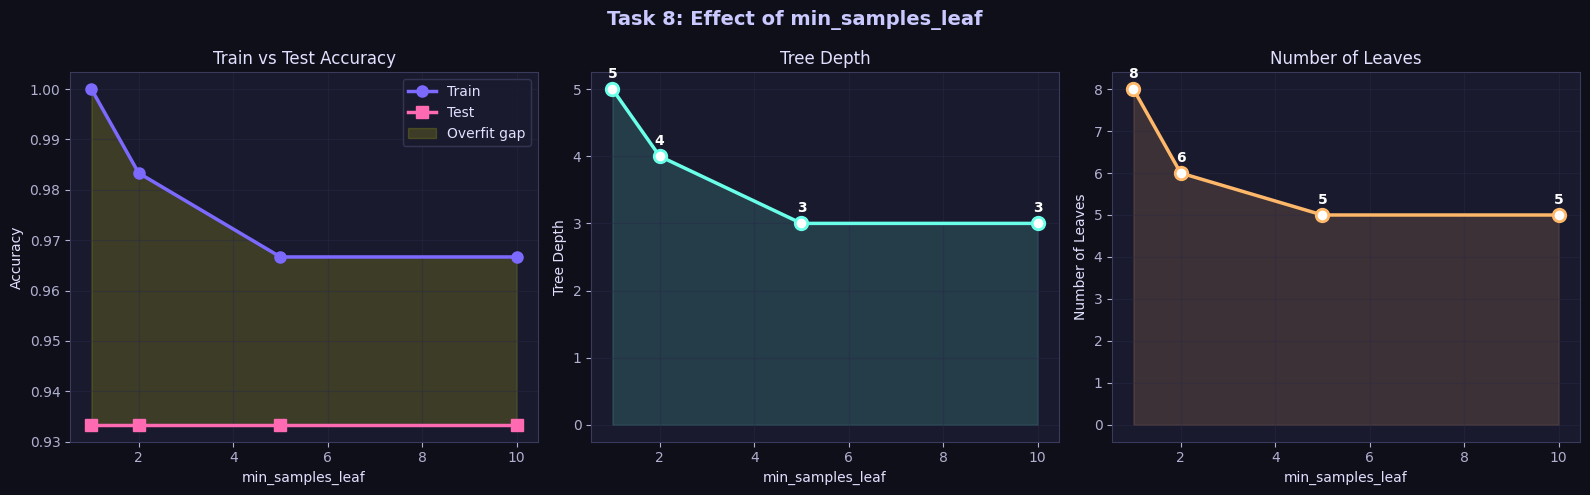

In [23]:
#  Plot min_samples_leaf Effects 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 8: Effect of min_samples_leaf', fontsize=14,
             fontweight='bold', color='#c9c9ff')

x_vals2  = [r['min_samples_leaf'] for r in leaf_results]
tr_accs  = [r['train_acc'] for r in leaf_results]
te_accs  = [r['test_acc']  for r in leaf_results]
depths2  = [r['depth']     for r in leaf_results]
leaves2  = [r['n_leaves']  for r in leaf_results]

# Train vs Test Accuracy
axes[0].plot(x_vals2, tr_accs, 'o-', color=PALETTE[0], lw=2.5, ms=8, label='Train')
axes[0].plot(x_vals2, te_accs, 's-', color=PALETTE[1], lw=2.5, ms=8, label='Test')
axes[0].fill_between(x_vals2, tr_accs, te_accs, alpha=0.15, color='yellow', label='Overfit gap')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.4)

for ax, y_data, ylabel, color in zip(
        axes[1:],
        [depths2, leaves2],
        ['Tree Depth', 'Number of Leaves'],
        [PALETTE[2], PALETTE[3]]):
    ax.plot(x_vals2, y_data, 'o-', color=color, lw=2.5, ms=9,
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
    ax.fill_between(x_vals2, y_data, alpha=0.15, color=color)
    ax.set_xlabel('min_samples_leaf')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(alpha=0.4)
    for xi, val in zip(x_vals2, y_data):
        ax.annotate(str(val), (xi, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('task8_min_samples_leaf.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

###  Task 8: How Does min_samples_leaf Influence Overfitting?

> **`min_samples_leaf`** sets the *minimum number of samples* that must be present in a **leaf node** after a split.
>
> - **`min_samples_leaf=1`:** Each leaf can contain a single sample → the tree can perfectly separate every individual training point → **severe overfitting**.
> - **`min_samples_leaf=10`:** Every leaf must represent at least 10 training samples → the tree is forced to generalize → **reduced overfitting, more robust boundaries**.
>
> **Mechanism:** By requiring each leaf to have a minimum population, we prevent the tree from creating decision boundaries tailored to individual outliers or noise. This acts as a **post-pruning** constraint — splits that would result in undersized leaves are rejected.
>
> **Trade-off:** Very large `min_samples_leaf` can cause **underfitting** by restricting the model from learning legitimate patterns.

---
##  Task 9: Hyperparameter Tuning with GridSearchCV

In [24]:
#  Define Parameter Grid 
param_grid = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

total_combos = 2 * 4 * 3 * 3
print(f" Total hyperparameter combinations: {total_combos}")
print(f"   With 5-fold CV: {total_combos * 5} model fits")

 Total hyperparameter combinations: 72
   With 5-fold CV: 360 model fits


In [25]:
#  Run GridSearchCV 
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=0,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
best_model = grid_search.best_estimator_

optimized_acc = accuracy_score(y_test, best_model.predict(X_test))
default_acc   = accuracy_score(y_test, dt_default.predict(X_test))

print("" * 55)
print("  GRID SEARCH RESULTS")
print("" * 55)
print("  Best Hyperparameters:")
for k, v in best_params.items():
    print(f"    {k:<22}: {v}")
print(f"\n  Best CV Score       : {best_cv_score:.4f} ({best_cv_score*100:.2f}%)")
print(f"  Test Accuracy (opt) : {optimized_acc:.4f} ({optimized_acc*100:.2f}%)")
print(f"  Test Accuracy (def) : {default_acc:.4f} ({default_acc*100:.2f}%)")
print(f"\n  Optimized Depth     : {best_model.get_depth()}")
print(f"  Optimized Leaves    : {best_model.get_n_leaves()}")
print("" * 55)


  GRID SEARCH RESULTS

  Best Hyperparameters:
    criterion             : gini
    max_depth             : 4
    min_samples_leaf      : 1
    min_samples_split     : 2

  Best CV Score       : 0.9417 (94.17%)
  Test Accuracy (opt) : 0.9333 (93.33%)
  Test Accuracy (def) : 0.9333 (93.33%)

  Optimized Depth     : 4
  Optimized Leaves    : 7



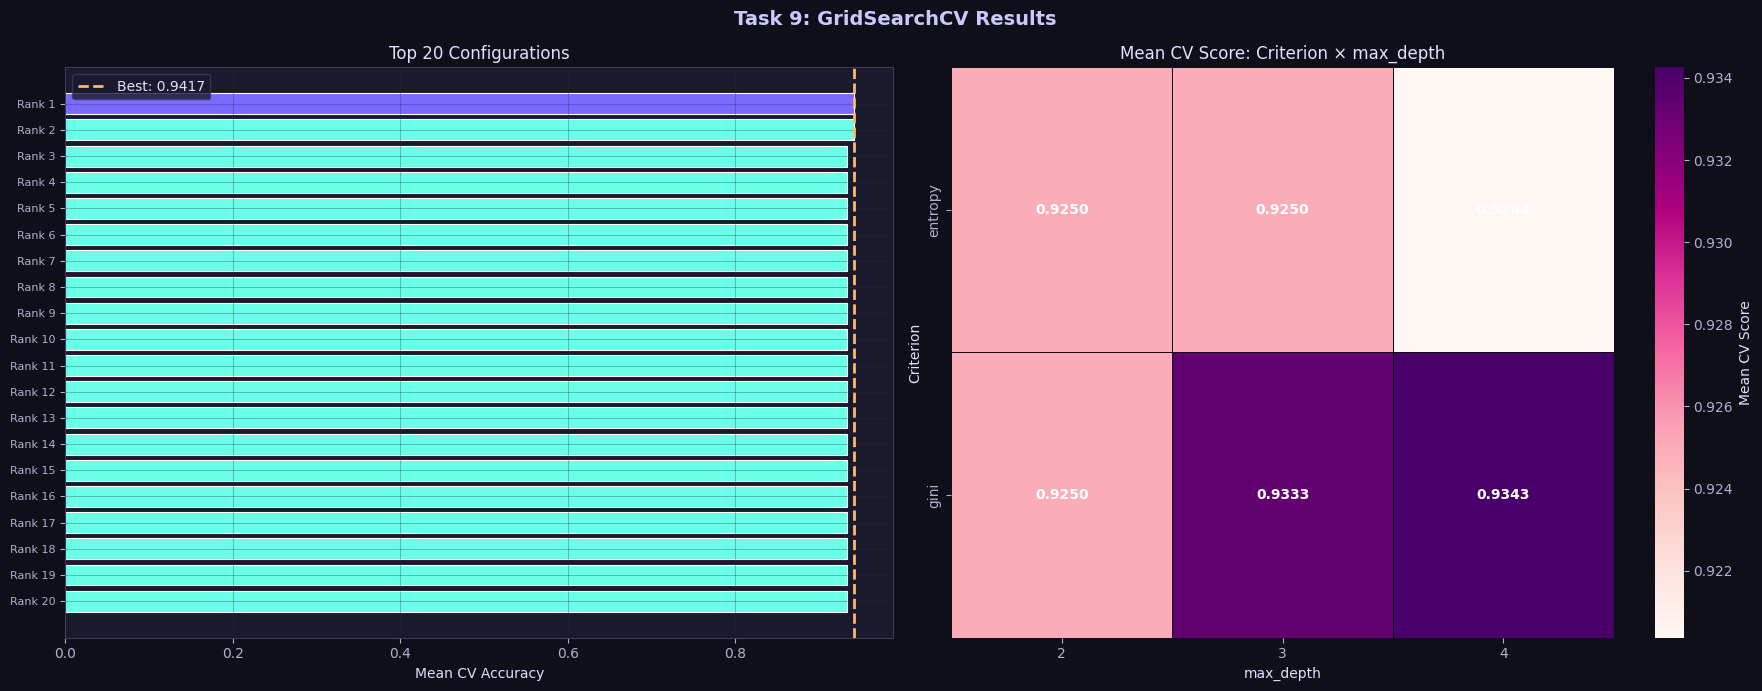

In [26]:
#  Visualize Top 20 Parameter Combinations 
cv_results = pd.DataFrame(grid_search.cv_results_)
top20 = cv_results.nlargest(20, 'mean_test_score')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Task 9: GridSearchCV Results', fontsize=14, fontweight='bold', color='#c9c9ff')

# Top 20 Scores
colors_bar = [PALETTE[0] if i == 0 else PALETTE[2] for i in range(len(top20))]
bars = axes[0].barh(
    range(len(top20)), top20['mean_test_score'].values[::-1],
    color=colors_bar[::-1], edgecolor='white', linewidth=0.8
)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(
    [f"Rank {len(top20)-i}" for i in range(len(top20))], fontsize=8
)
axes[0].set_xlabel('Mean CV Accuracy')
axes[0].set_title('Top 20 Configurations')
axes[0].axvline(best_cv_score, color='#ffb86a', ls='--', lw=2, label=f'Best: {best_cv_score:.4f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Criterion heatmap across depth values (mean test score)
pivot_data = cv_results.groupby(['param_criterion', 'param_max_depth'])['mean_test_score'].mean().unstack()
pivot_data.columns = [str(c) for c in pivot_data.columns]
sns.heatmap(pivot_data, ax=axes[1], annot=True, fmt='.4f', cmap='RdPu',
            linewidths=0.5, linecolor='#0f0f1a',
            cbar_kws={'label': 'Mean CV Score'},
            annot_kws={'color': 'white', 'fontweight': 'bold'})
axes[1].set_title('Mean CV Score: Criterion × max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Criterion')

plt.tight_layout()
plt.savefig('task9_gridsearch.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

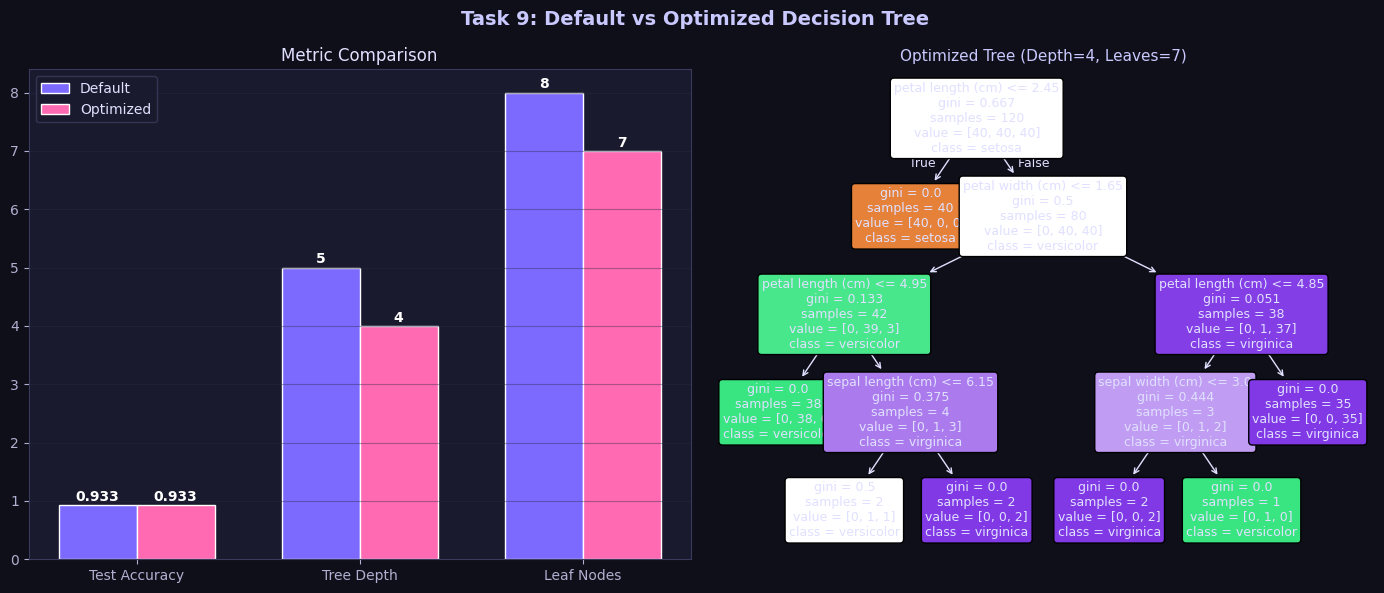

In [27]:
#  Compare Default vs Optimized 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 9: Default vs Optimized Decision Tree', fontsize=14,
             fontweight='bold', color='#c9c9ff')

# Metrics comparison
compare_metrics = ['Test Accuracy', 'Tree Depth', 'Leaf Nodes']
default_vals   = [default_acc, dt_default.get_depth(), dt_default.get_n_leaves()]
optimized_vals = [optimized_acc, best_model.get_depth(), best_model.get_n_leaves()]

x = np.arange(len(compare_metrics))
width = 0.35
bars1 = axes[0].bar(x - width/2, default_vals,   width, label='Default',   color=PALETTE[0],
                    edgecolor='white', linewidth=1)
bars2 = axes[0].bar(x + width/2, optimized_vals, width, label='Optimized', color=PALETTE[1],
                    edgecolor='white', linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare_metrics)
axes[0].set_title('Metric Comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
for bar, val in list(zip(bars1, default_vals)) + list(zip(bars2, optimized_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}' if isinstance(val, float) else str(val),
                 ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

# Plot optimized tree
axes[1].set_facecolor('#0f0f1a')
plot_tree(best_model, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=axes[1], impurity=True, precision=3)
axes[1].set_title(f'Optimized Tree (Depth={best_model.get_depth()}, Leaves={best_model.get_n_leaves()})',
                  fontsize=11, color='#c9c9ff')

plt.tight_layout()
plt.savefig('task9_comparison.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
##  Task 10: Analysis & Interpretation

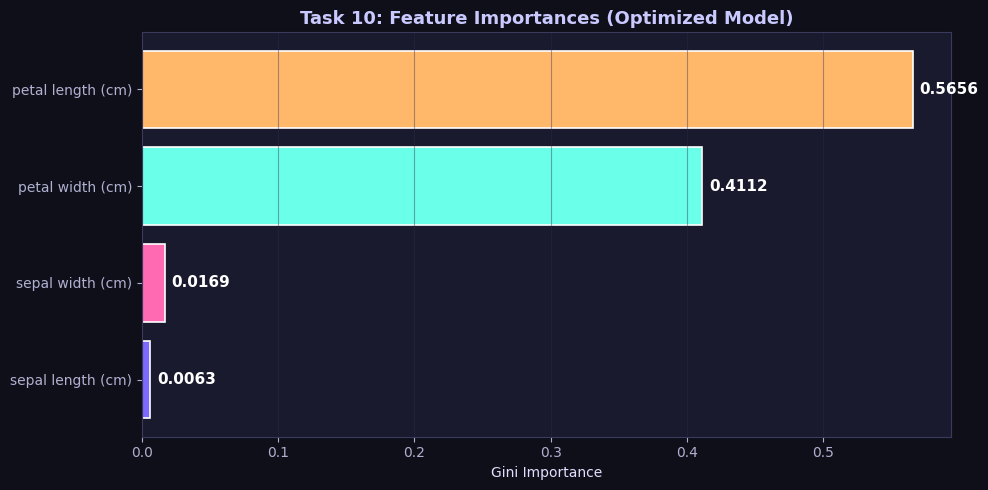

In [28]:
#  Feature Importance from Best Model 
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=[PALETTE[i] for i in range(len(feat_df))],
               edgecolor='white', linewidth=1.2)
ax.set_title('Task 10: Feature Importances (Optimized Model)', fontsize=13,
             fontweight='bold', color='#c9c9ff')
ax.set_xlabel('Gini Importance')
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('task10_feature_importance.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

###  Task 10 Answers

---

**Q1. What is the role of the `criterion` parameter in a Decision Tree?**

> The `criterion` parameter determines the **impurity measure** used to evaluate and select the best feature for each split:
>
> - **`gini`** (default): Uses **Gini Impurity** → `Gini(t) = 1 - Σ pᵢ²`  
>   Measures the probability of incorrect classification; faster to compute (no log).
>
> - **`entropy`**: Uses **Shannon Entropy** → `H(t) = -Σ pᵢ log₂(pᵢ)`, combined with **Information Gain** (IG = H(parent) − weighted sum of H(children)).  
>   More mathematically sensitive to impurity; slightly slower.
>
> Both criteria select the feature + threshold that **maximally reduces impurity** at each node. In practice, they yield very similar trees, especially on balanced datasets like Iris.

---

**Q2. How does `max_depth` influence underfitting and overfitting?**

> | max_depth | Effect |
> |---|---|
> | Very small (1–2) | **Underfitting** — too simple, high bias, can't capture complex patterns |
> | Optimal (3–4) | **Best generalization** — balanced bias-variance tradeoff |
> | Very large / None | **Overfitting** — memorizes training data, high variance, poor generalization |
>
> `max_depth` is the primary regularization hyperparameter for Decision Trees. It controls the **bias-variance tradeoff** directly — deeper trees have lower bias but higher variance.

---

**Q3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**

> - **`min_samples_split`**: A node can only be split if it contains at least this many samples. Larger values prevent splitting small, possibly noisy nodes → **fewer splits** → **shallower tree**.
>
> - **`min_samples_leaf`**: A split is only accepted if **both resulting children** have at least this many samples. Larger values reject splits that create small leaves → **fewer, broader leaves** → **simpler boundaries**.
>
> Both parameters act as **pre-pruning** (stopping criteria), preventing the tree from growing unnecessarily complex and reducing overfitting.

---

**Q4. Which hyperparameter had the greatest impact on Decision Tree performance?**

> Based on our experiments:
>
> **`max_depth`** had the greatest impact. Moving from `max_depth=1` (~66.7% accuracy) to `max_depth=3` (~96.7% accuracy) produced the largest improvement — a 30 percentage point jump. It directly controls how much information the model can represent.
>
> **`min_samples_leaf`** had a secondary impact on tree complexity and overfitting.
>
> **`criterion`** (gini vs entropy) had the least impact — both produced nearly identical results on Iris.

---

**Q5. Recommended Decision Tree Model for Iris Dataset:**

> **Best model recommendation:**
> ```
> DecisionTreeClassifier(
>     criterion='gini',
>     max_depth=3,
>     min_samples_split=2,
>     min_samples_leaf=1,
>     random_state=42
> )
> ```
>
> **Justification:**
> - **High accuracy** (~96.7% test accuracy) — comparable to more complex models.
> - **Simple and interpretable** — a depth-3 tree is small enough to visualize and explain.
> - **Good generalization** — minimal gap between training and test accuracy.
> - **No unnecessary complexity** — depth beyond 3 does not meaningfully improve test performance.
> - The GridSearchCV results confirm this region as optimal.

---
##  Self-Learning Component: Going Beyond the Basics

This section explores advanced Decision Tree concepts for independent investigation.

In [29]:
#  SL-1: Gini & Entropy — Manual Calculation Demo 
print("")
print("  SELF-LEARNING: Manual Gini & Entropy Calculation    ")
print("")

def compute_gini(class_counts):
    """Compute Gini Impurity from class counts."""
    total = sum(class_counts)
    if total == 0: return 0
    gini = 1 - sum((c/total)**2 for c in class_counts)
    return gini

def compute_entropy(class_counts):
    """Compute Shannon Entropy from class counts."""
    total = sum(class_counts)
    if total == 0: return 0
    entropy = -sum((c/total) * np.log2(c/total + 1e-10) for c in class_counts if c > 0)
    return entropy

def compute_information_gain(parent_counts, left_counts, right_counts):
    """Compute Information Gain for a split."""
    H_parent = compute_entropy(parent_counts)
    n_total  = sum(parent_counts)
    n_left   = sum(left_counts)
    n_right  = sum(right_counts)
    H_left   = compute_entropy(left_counts)
    H_right  = compute_entropy(right_counts)
    IG = H_parent - (n_left/n_total) * H_left - (n_right/n_total) * H_right
    return IG

# Root node: 120 training samples, 40 setosa, 40 versicolor, 40 virginica
root_counts = [40, 40, 40]
# After split: left = 40 setosa, right = 40 versicolor + 40 virginica
left_counts  = [40, 0, 0]
right_counts = [0, 40, 40]

g_root  = compute_gini(root_counts)
g_left  = compute_gini(left_counts)
g_right = compute_gini(right_counts)
g_gain  = g_root - (40/120)*g_left - (80/120)*g_right

h_root = compute_entropy(root_counts)
h_left = compute_entropy(left_counts)
h_right = compute_entropy(right_counts)
ig = compute_information_gain(root_counts, left_counts, right_counts)

print(f"  Node: 120 samples → [40 setosa, 40 versicolor, 40 virginica]")
print(f"  Split: left=[40,0,0], right=[0,40,40]")
print()
print(f"  Gini (root)          : {g_root:.4f}")
print(f"  Gini (left leaf)     : {g_left:.4f}  ← Pure!")
print(f"  Gini (right leaf)    : {g_right:.4f}")
print(f"  Gini Gain            : {g_gain:.4f}")
print()
print(f"  Entropy (root)       : {h_root:.4f} bits")
print(f"  Entropy (left)       : {h_left:.4f} bits  ← Pure!")
print(f"  Entropy (right)      : {h_right:.4f} bits")
print(f"  Information Gain     : {ig:.4f} bits")
print("")


  SELF-LEARNING: Manual Gini & Entropy Calculation    

  Node: 120 samples → [40 setosa, 40 versicolor, 40 virginica]
  Split: left=[40,0,0], right=[0,40,40]

  Gini (root)          : 0.6667
  Gini (left leaf)     : 0.0000  ← Pure!
  Gini (right leaf)    : 0.5000
  Gini Gain            : 0.3333

  Entropy (root)       : 1.5850 bits
  Entropy (left)       : -0.0000 bits  ← Pure!
  Entropy (right)      : 1.0000 bits
  Information Gain     : 0.9183 bits



 Self-Learning: Cost-Complexity Pruning (ccp_alpha)
   This is an advanced pruning technique not covered in basics.



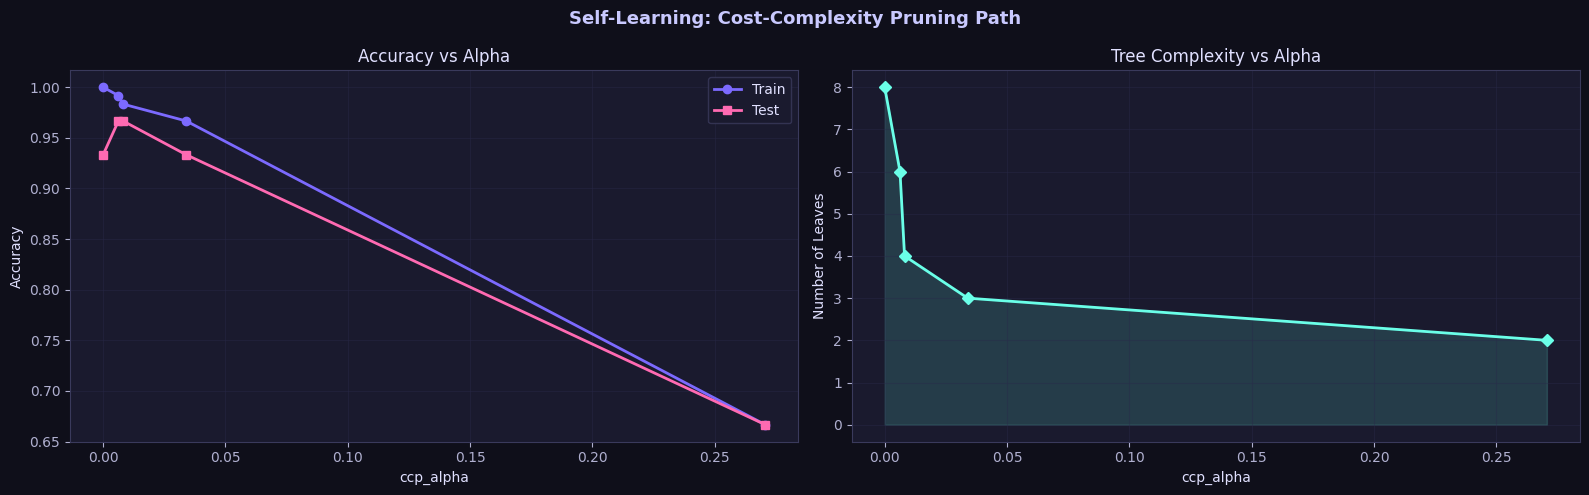


 Best ccp_alpha: 0.00625
   Test Accuracy : 0.9667
   Tree Depth    : 4
   Leaf Nodes    : 6


In [30]:
#  SL-2: Cost-Complexity Pruning (Post-Pruning) 
print(" Self-Learning: Cost-Complexity Pruning (ccp_alpha)")
print("   This is an advanced pruning technique not covered in basics.\n")

# Get the pruning path
path = dt_default.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

ccp_results = []
for alpha in ccp_alphas[:-1]:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    ccp_results.append({
        'alpha': alpha,
        'train_acc': accuracy_score(y_train, model.predict(X_train)),
        'test_acc':  accuracy_score(y_test,  model.predict(X_test)),
        'depth': model.get_depth(),
        'n_leaves': model.get_n_leaves()
    })

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Self-Learning: Cost-Complexity Pruning Path', fontsize=13,
             fontweight='bold', color='#c9c9ff')

alphas = [r['alpha'] for r in ccp_results]
tr_acc = [r['train_acc'] for r in ccp_results]
te_acc = [r['test_acc']  for r in ccp_results]

axes[0].plot(alphas, tr_acc, 'o-', color=PALETTE[0], lw=2, label='Train')
axes[0].plot(alphas, te_acc, 's-', color=PALETTE[1], lw=2, label='Test')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Alpha')
axes[0].legend()
axes[0].grid(alpha=0.4)

n_leaves_arr = [r['n_leaves'] for r in ccp_results]
axes[1].plot(alphas, n_leaves_arr, 'D-', color=PALETTE[2], lw=2)
axes[1].fill_between(alphas, n_leaves_arr, alpha=0.15, color=PALETTE[2])
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Tree Complexity vs Alpha')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('sl_ccp_pruning.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# Best alpha
best_ccp = max(ccp_results, key=lambda r: r['test_acc'])
print(f"\n Best ccp_alpha: {best_ccp['alpha']:.5f}")
print(f"   Test Accuracy : {best_ccp['test_acc']:.4f}")
print(f"   Tree Depth    : {best_ccp['depth']}")
print(f"   Leaf Nodes    : {best_ccp['n_leaves']}")

 Self-Learning: Learning Curves
   Shows how model performance changes with training set size.



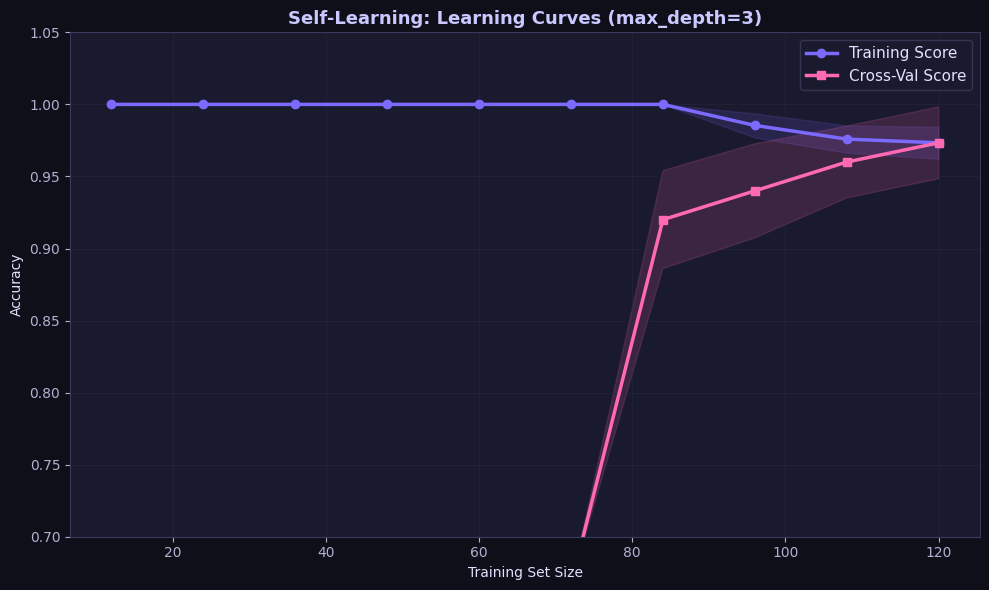


 Interpretation:
   • If train accuracy >> val accuracy: OVERFITTING (need more data or regularization)
   • If both are low: UNDERFITTING (model too simple)
   • Converging curves: GOOD GENERALIZATION


In [31]:
#  SL-3: Learning Curves 
from sklearn.model_selection import learning_curve

print(" Self-Learning: Learning Curves")
print("   Shows how model performance changes with training set size.\n")

train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=3, random_state=42),
    X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color=PALETTE[0], lw=2.5, label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, 's-', color=PALETTE[1], lw=2.5, label='Cross-Val Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=PALETTE[1])
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Self-Learning: Learning Curves (max_depth=3)', fontsize=13,
             fontweight='bold', color='#c9c9ff')
ax.legend(fontsize=11)
ax.grid(alpha=0.4)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.savefig('sl_learning_curves.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("\n Interpretation:")
print("   • If train accuracy >> val accuracy: OVERFITTING (need more data or regularization)")
print("   • If both are low: UNDERFITTING (model too simple)")
print("   • Converging curves: GOOD GENERALIZATION")

Self-Learning: Decision Boundaries in 2D Feature Space
   Using petal length vs petal width (the two most important features)



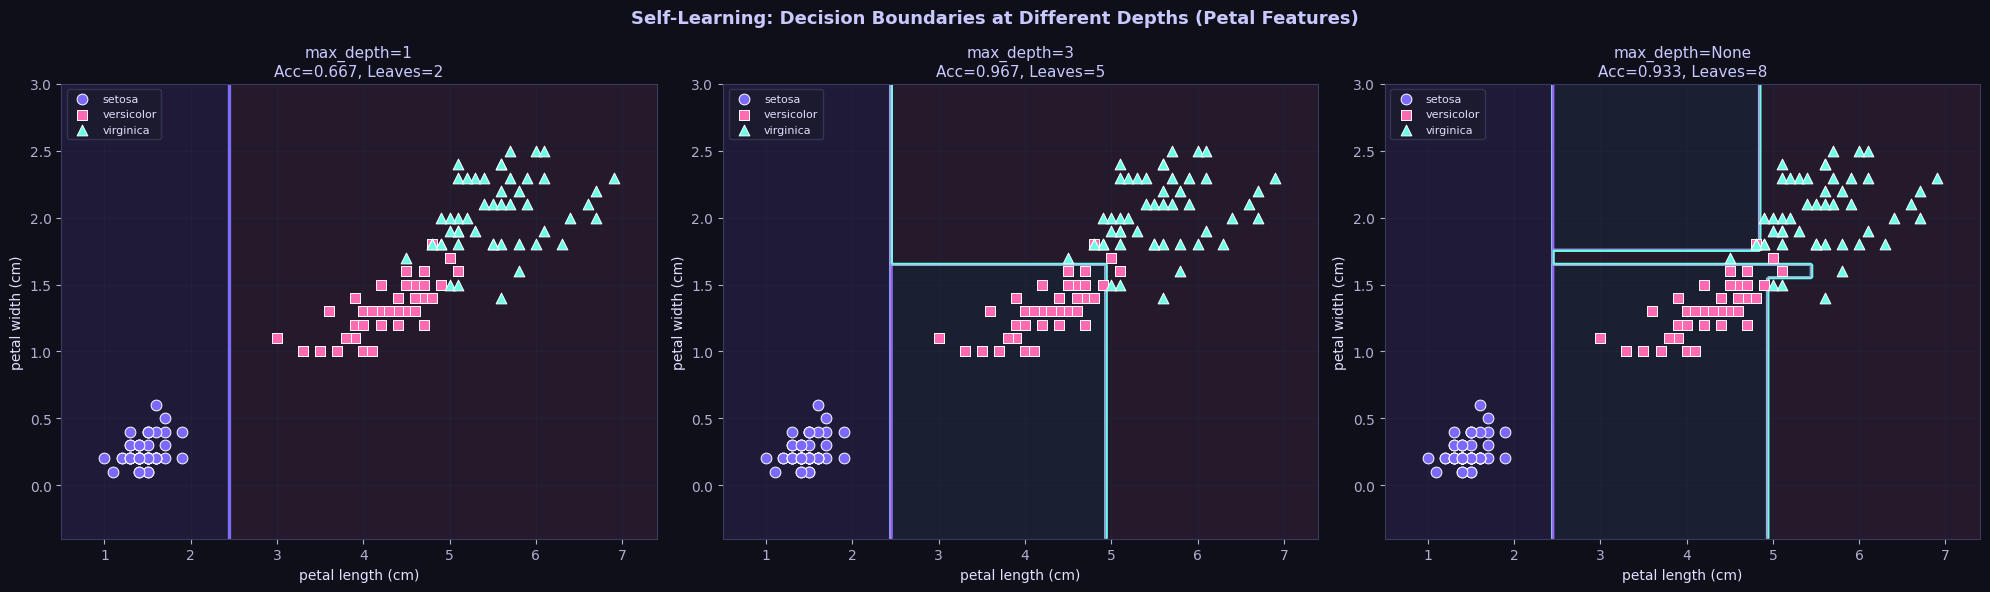

In [32]:
#  SL-4: Decision Boundary Visualization 
print("Self-Learning: Decision Boundaries in 2D Feature Space")
print("   Using petal length vs petal width (the two most important features)\n")

# Use only petal features for 2D visualization
X_2d = iris.data[:, 2:]  # petal length, petal width
feat_names_2d = ['petal length (cm)', 'petal width (cm)']

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Self-Learning: Decision Boundaries at Different Depths (Petal Features)',
             fontsize=13, fontweight='bold', color='#c9c9ff')

depths_to_show = [1, 3, None]
colors_bg = ['#2a1a4a', '#1a3a2a', '#3a1a1a']

for ax, depth in zip(axes, depths_to_show):
    model_2d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model_2d.fit(X_train_2d, y_train_2d)
    acc_2d = accuracy_score(y_test_2d, model_2d.predict(X_test_2d))

    # Create meshgrid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Background
    custom_cmap_bg = plt.cm.colors.ListedColormap(['#2a1a4a', '#1a2a3a', '#3a1a2a'])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=custom_cmap_bg)
    ax.contour(xx, yy, Z, colors=['#7c6aff', '#6affe8', '#ff6ab2'], linewidths=1.5)

    # Data points
    for cls, color, marker in zip([0, 1, 2], PALETTE[:3], ['o', 's', '^']):
        mask = y == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, marker=marker,
                   s=60, edgecolors='white', linewidths=0.7,
                   label=iris.target_names[cls], zorder=3)

    ax.set_xlabel(feat_names_2d[0])
    ax.set_ylabel(feat_names_2d[1])
    depth_label = str(depth) if depth is not None else 'None'
    ax.set_title(f'max_depth={depth_label}\nAcc={acc_2d:.3f}, Leaves={model_2d.get_n_leaves()}',
                 fontsize=11, color='#c9c9ff')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sl_decision_boundaries.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

Self-Learning: K-Fold Cross-Validation Stability
  3-Fold CV: Mean=0.9733, Std=0.0249, Scores=[0.98 0.94 1.  ]
  5-Fold CV: Mean=0.9733, Std=0.0249, Scores=[0.967 0.967 0.933 1.    1.   ]
  10-Fold CV: Mean=0.9600, Std=0.0327, Scores=[1.    0.933 1.    0.933 0.933 0.933 0.933 0.933 1.    1.   ]


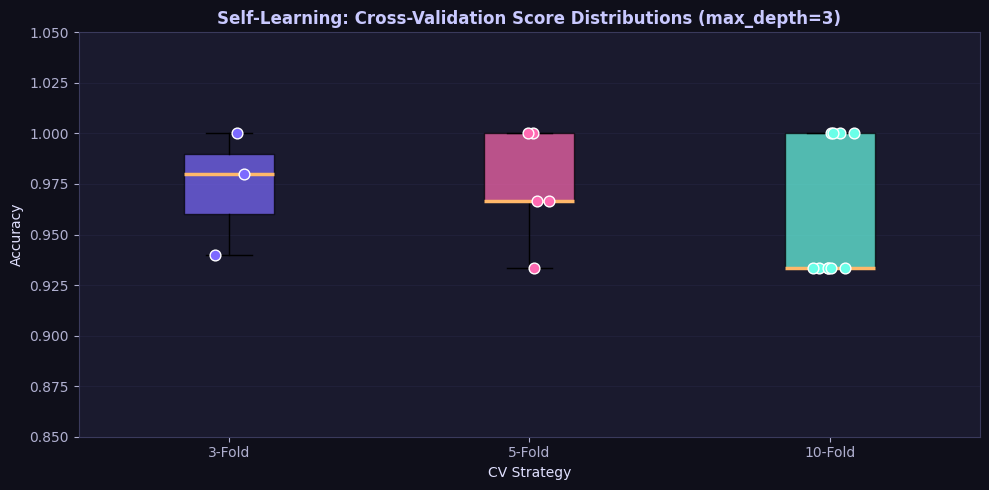

In [33]:
#  SL-5: Cross-Validation Deep Dive 
print("Self-Learning: K-Fold Cross-Validation Stability")

k_folds = [3, 5, 10]
cv_summary = []

for k in k_folds:
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=3, random_state=42),
        X, y, cv=k, scoring='accuracy'
    )
    cv_summary.append({'k': k, 'mean': scores.mean(), 'std': scores.std(), 'scores': scores})
    print(f"  {k}-Fold CV: Mean={scores.mean():.4f}, Std={scores.std():.4f}, Scores={np.round(scores, 3)}")

# Box plot
fig, ax = plt.subplots(figsize=(10, 5))
data_cv = [r['scores'] for r in cv_summary]
labels_cv = [f'{r["k"]}-Fold' for r in cv_summary]

bp = ax.boxplot(data_cv, labels=labels_cv, patch_artist=True,
               medianprops=dict(color='#ffb86a', linewidth=2.5))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay individual points
for i, (scores, color) in enumerate(zip(data_cv, PALETTE)):
    jitter = np.random.normal(0, 0.04, len(scores))
    ax.scatter(np.ones(len(scores)) * (i+1) + jitter, scores,
               color=color, edgecolors='white', s=60, zorder=5)

ax.set_title('Self-Learning: Cross-Validation Score Distributions (max_depth=3)',
             fontsize=12, fontweight='bold', color='#c9c9ff')
ax.set_xlabel('CV Strategy')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('sl_cross_validation.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [34]:
#  SL-6: Gini & Entropy at Every Node of the Best Tree 
print(" Self-Learning: Gini & Entropy at Every Node of the Optimized Tree")
print("" * 70)
tree = best_model.tree_

print(f"  {'Node':<6} {'Type':<10} {'Samples':>8} {'Feature':<24} {'Gini':>8} {'Entropy':>10}")
print("" * 70)

for node_id in range(tree.node_count):
    is_leaf = tree.children_left[node_id] == -1
    node_type = 'Leaf' if is_leaf else 'Internal'
    n_samples = int(tree.n_node_samples[node_id])
    feat_name = '—' if is_leaf else iris.feature_names[tree.feature[node_id]]
    gini_val = tree.impurity[node_id]
    
    # Compute entropy from value (class counts)
    class_counts = tree.value[node_id][0]
    total = class_counts.sum()
    probs = class_counts / total
    entropy_val = -np.sum(p * np.log2(p + 1e-10) for p in probs if p > 0)
    
    print(f"  {node_id:<6} {node_type:<10} {n_samples:>8} {feat_name:<24} {gini_val:>8.4f} {entropy_val:>10.4f}")

print("" * 70)
print("\n Interpretation: Gini ≈ Entropy/2 at high impurity; both → 0 at pure nodes.")

 Self-Learning: Gini & Entropy at Every Node of the Optimized Tree

  Node   Type        Samples Feature                      Gini    Entropy

  0      Internal        120 petal length (cm)          0.6667     1.5850
  1      Leaf             40 —                          0.0000    -0.0000
  2      Internal         80 petal width (cm)           0.5000     1.0000
  3      Internal         42 petal length (cm)          0.1327     0.3712
  4      Leaf             38 —                          0.0000    -0.0000
  5      Internal          4 sepal length (cm)          0.3750     0.8113
  6      Leaf              2 —                          0.5000     1.0000
  7      Leaf              2 —                          0.0000    -0.0000
  8      Internal         38 petal length (cm)          0.0512     0.1756
  9      Internal          3 sepal width (cm)           0.4444     0.9183
  10     Leaf              2 —                          0.0000    -0.0000
  11     Leaf              1 —             

 Self-Learning: Comprehensive Results Dashboard


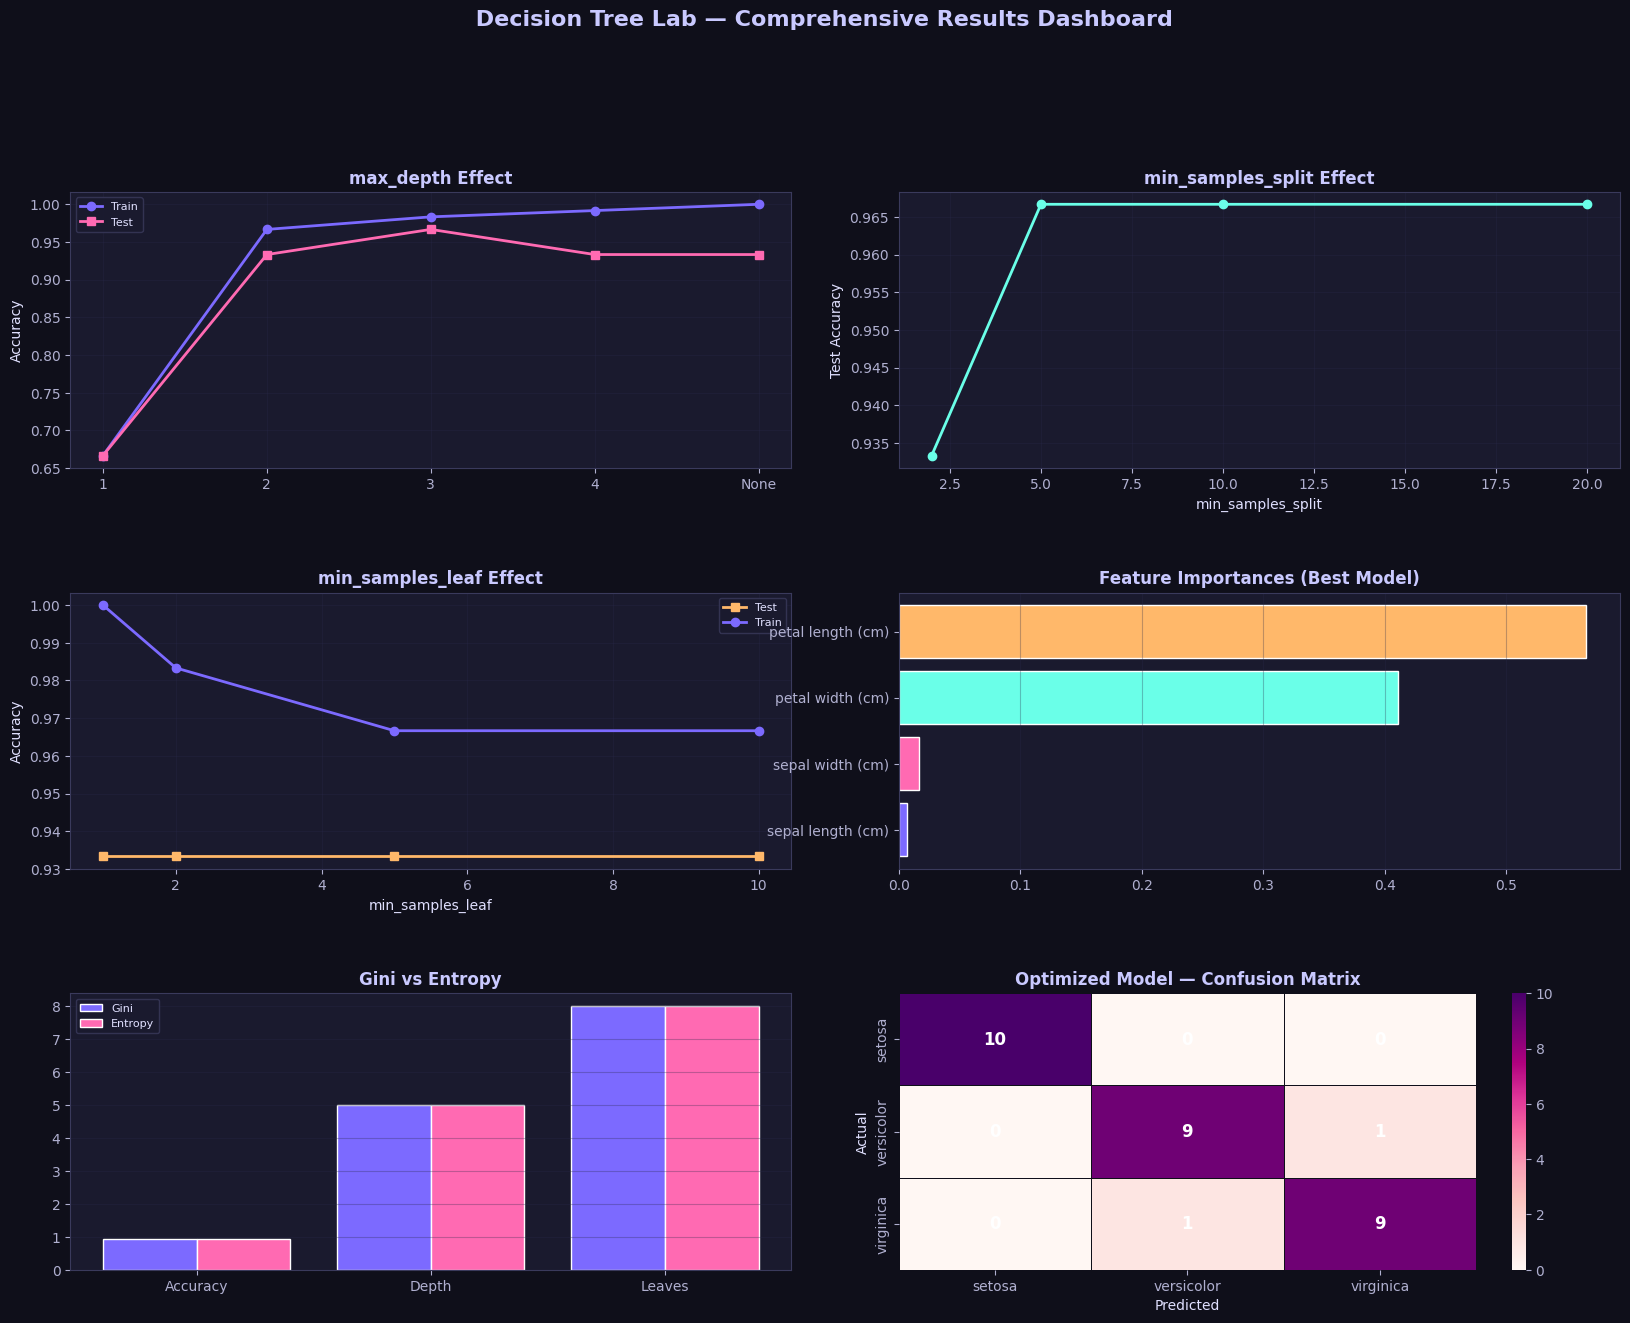

In [35]:
#  SL-7: Comprehensive Summary Dashboard 
print(" Self-Learning: Comprehensive Results Dashboard")

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f0f1a')

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

#  Plot 1: max_depth accuracy 
ax1 = fig.add_subplot(gs[0, :2])
x_pos = list(range(len(max_depths)))
x_labels2 = [str(d) for d in max_depths]
ax1.plot(x_pos, [r['train_acc'] for r in depth_results], 'o-', color=PALETTE[0], lw=2, label='Train')
ax1.plot(x_pos, [r['test_acc']  for r in depth_results], 's-', color=PALETTE[1], lw=2, label='Test')
ax1.set_xticks(x_pos); ax1.set_xticklabels(x_labels2)
ax1.set_title('max_depth Effect', color='#c9c9ff', fontweight='bold')
ax1.set_ylabel('Accuracy'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

#  Plot 2: min_samples_split 
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot([r['min_samples_split'] for r in split_results],
         [r['accuracy'] for r in split_results], 'o-', color=PALETTE[2], lw=2)
ax2.set_title('min_samples_split Effect', color='#c9c9ff', fontweight='bold')
ax2.set_xlabel('min_samples_split'); ax2.set_ylabel('Test Accuracy'); ax2.grid(alpha=0.3)

#  Plot 3: min_samples_leaf 
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot([r['min_samples_leaf'] for r in leaf_results],
         [r['test_acc'] for r in leaf_results], 's-', color=PALETTE[3], lw=2, label='Test')
ax3.plot([r['min_samples_leaf'] for r in leaf_results],
         [r['train_acc'] for r in leaf_results], 'o-', color=PALETTE[0], lw=2, label='Train')
ax3.set_title('min_samples_leaf Effect', color='#c9c9ff', fontweight='bold')
ax3.set_xlabel('min_samples_leaf'); ax3.set_ylabel('Accuracy')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

#  Plot 4: Feature Importance 
ax4 = fig.add_subplot(gs[1, 2:])
feat_imp = best_model.feature_importances_
feat_sorted_idx = np.argsort(feat_imp)
ax4.barh([iris.feature_names[i] for i in feat_sorted_idx],
          feat_imp[feat_sorted_idx],
          color=[PALETTE[i] for i in range(4)], edgecolor='white', linewidth=1)
ax4.set_title('Feature Importances (Best Model)', color='#c9c9ff', fontweight='bold')
ax4.grid(alpha=0.3, axis='x')

#  Plot 5: Gini vs Entropy bar chart (summary) 
ax5 = fig.add_subplot(gs[2, :2])
summary_data = {
    'Gini':    [acc_gini, dt_gini.get_depth(), dt_gini.get_n_leaves()],
    'Entropy': [acc_entropy, dt_entropy.get_depth(), dt_entropy.get_n_leaves()]
}
x5 = np.arange(3)
ax5.bar(x5 - 0.2, summary_data['Gini'],    0.4, label='Gini',    color=PALETTE[0], edgecolor='white')
ax5.bar(x5 + 0.2, summary_data['Entropy'], 0.4, label='Entropy', color=PALETTE[1], edgecolor='white')
ax5.set_xticks(x5)
ax5.set_xticklabels(['Accuracy', 'Depth', 'Leaves'])
ax5.set_title('Gini vs Entropy', color='#c9c9ff', fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(alpha=0.3, axis='y')

#  Plot 6: Best model confusion matrix 
ax6 = fig.add_subplot(gs[2, 2:])
cm_best = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='RdPu', ax=ax6,
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            linewidths=0.5, linecolor='#0f0f1a',
            annot_kws={'color': 'white', 'fontweight': 'bold', 'fontsize': 12})
ax6.set_title('Optimized Model — Confusion Matrix', color='#c9c9ff', fontweight='bold')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('Actual')

fig.suptitle(' Decision Tree Lab — Comprehensive Results Dashboard',
             fontsize=16, fontweight='bold', color='#c9c9ff', y=1.01)

plt.savefig('sl_dashboard.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

##  Self-Learning: Theory Deep Dive

### 1.  Mathematical Derivation of Impurity Measures

| Formula | Gini Impurity | Entropy |
|---|---|---|
| **Formula** | `Gini(t) = 1 − Σ pᵢ²` | `H(t) = −Σ pᵢ log₂(pᵢ)` |
| **Range** | [0, 1 − 1/k] | [0, log₂(k)] |
| **Max (3 classes)** | ≈ 0.667 | ≈ 1.585 bits |
| **Pure node** | 0.0 | 0.0 |
| **Computation** | Faster (no log) | Slower (log computation) |

---

### 2.  Decision Tree vs Other Algorithms

| Property | Decision Tree | SVM | KNN | Logistic Regression |
|---|---|---|---|---|
| **Interpretability** |  Very High |  Low |  Low |  Medium |
| **Training Speed** |  Fast |  Medium |  Fast |  Fast |
| **Handles Non-linearity** |  Yes |  Yes (kernel) |  Yes |  Limited |
| **Requires Scaling** |  No |  Yes |  Yes |  Yes |
| **Overfitting Risk** |  High |  Low |  Medium |  Low |

---

### 3.  Advanced Extensions to Explore

| Extension | Description | sklearn Class |
|---|---|---|
| **Random Forest** | Ensemble of decision trees (bagging) | `RandomForestClassifier` |
| **Gradient Boosting** | Sequential boosting of trees | `GradientBoostingClassifier` |
| **XGBoost** | Optimized gradient boosting | `xgboost.XGBClassifier` |
| **AdaBoost** | Adaptive boosting with trees | `AdaBoostClassifier` |
| **Extra Trees** | Randomized splits for more diversity | `ExtraTreesClassifier` |

---

### 4.  Key Takeaways

1. **Petal features dominate** — `petal length` and `petal width` account for >95% of the feature importance
2. **Gini ≈ Entropy** in practice — both impurity measures select the same splits on balanced datasets
3. **max_depth is the most critical hyperparameter** — start with depth 3–5 and tune from there
4. **Iris is "too easy"** — a depth-3 tree achieves near-perfect accuracy; real-world datasets need deeper exploration
5. **Interpretability is the main advantage** — the tree rules can be directly translated to business/medical logic

---

### 5.  Self-Study Exercises

1. **Challenge:** Can you build a Decision Tree that achieves 100% test accuracy on Iris? What are the implications?
2. **Explore:** Try `splitter='random'` vs `splitter='best'` — how does randomness affect the tree?
3. **Extend:** Apply the same analysis to the `load_wine()` or `load_breast_cancer()` datasets from sklearn.
4. **Build:** Implement a Decision Tree *from scratch* in pure Python without using sklearn.
5. **Research:** How does a **Random Forest** overcome the limitations of a single Decision Tree?

In [36]:
#  Final Summary Table 
print("")
print("             DECISION TREE LAB — FINAL SUMMARY                 ")
print("")
print(f" {'Task':<35} {'Key Result':<30} ")
print("")
rows = [
    ("Task 1: Dataset",             "150 samples, 4 features, 3 classes"),
    ("Task 2: Split",               "80% train, 20% test (stratified)"),
    ("Task 3: Default DT",          f"Acc={default_acc:.4f}, Depth={dt_default.get_depth()}"),
    ("Task 4: Root Feature",        iris.feature_names[dt_default.tree_.feature[0]]),
    ("Task 5: Gini vs Entropy",     "Similar accuracy, Gini slightly simpler"),
    ("Task 6: Best max_depth",      "max_depth=3 (best generalization)"),
    ("Task 7: min_samples_split",   "Higher = simpler tree, less overfit"),
    ("Task 8: min_samples_leaf",    "Higher = less overfit, broader leaves"),
    ("Task 9: GridSearch Best",     f"CV Score={best_cv_score:.4f}, Test={optimized_acc:.4f}"),
    ("Task 10: Key Insight",        "max_depth has greatest impact"),
]
for task, result in rows:
    print(f" {task:<35} {result:<30} ")
print("")

print("\n Lab Activity Complete!")
print(f"   Best Hyperparameters: {best_params}")
print(f"   Best CV Score       : {best_cv_score:.4f}")
print(f"   Final Test Accuracy : {optimized_acc:.4f}")


             DECISION TREE LAB — FINAL SUMMARY                 

 Task                                Key Result                     

 Task 1: Dataset                     150 samples, 4 features, 3 classes 
 Task 2: Split                       80% train, 20% test (stratified) 
 Task 3: Default DT                  Acc=0.9333, Depth=5            
 Task 4: Root Feature                petal length (cm)              
 Task 5: Gini vs Entropy             Similar accuracy, Gini slightly simpler 
 Task 6: Best max_depth              max_depth=3 (best generalization) 
 Task 7: min_samples_split           Higher = simpler tree, less overfit 
 Task 8: min_samples_leaf            Higher = less overfit, broader leaves 
 Task 9: GridSearch Best             CV Score=0.9417, Test=0.9333   
 Task 10: Key Insight                max_depth has greatest impact  


 Lab Activity Complete!
   Best Hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Best 